In [1]:
# ── Core Data ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)     # show all columns in prints
pd.set_option('display.float_format', '{:.4f}'.format)  # cleaner floats
 # ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
 # ── Graph ─────────────────────────────────────────────────────
import networkx as nx
from node2vec import Node2Vec
 # ── Machine Learning — Sklearn ────────────────────────────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import (RandomForestRegressor,RandomForestClassifier,
                              GradientBoostingRegressor,StackingRegressor)
                               
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,confusion_matrix, 
                              r2_score, classification_report,accuracy_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
 # ── Machine Learning — Boosting ───────────────────────────────
import xgboost as xgb
import lightgbm as lgb
 # ── Hyperparameter Tuning ─────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose logs
 # ── Stats ─────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import skew, kurtosis
from collections import defaultdict
 # ── System ────────────────────────────────────────────────────
import joblib
import pickle
import os
import time
 # ── Plot Style ────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi']     = 100
 
print("=" * 55)
print("All libraries imported successfully")
print(f"  pandas    : {pd.__version__}")
print(f"  numpy     : {np.__version__}")
print(f"  xgboost   : {xgb.__version__}")
print(f"  lightgbm  : {lgb.__version__}")
print(f"  optuna    : {optuna.__version__}")
print("=" * 55)

All libraries imported successfully
  pandas    : 2.3.3
  numpy     : 1.26.4
  xgboost   : 3.2.0
  lightgbm  : 4.6.0
  optuna    : 4.9.0


In [101]:
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
# Target column we are predicting
TARGET = 'segment_actual_time'
 
# Delay ratio thresholds
MIN_DELAY_RATIO  = 0.3    # below this = impossibly fast = data error
MAX_DELAY_RATIO  = 5.0    # above this = impossibly slow = data error
SLA_BREACH_RATIO = 1.2    # >20% over OSRM = SLA breach
 
# Speed thresholds for truck validation (km/h)
MIN_SPEED_KMH = 1
MAX_SPEED_KMH = 120
 
# Random seed for reproducibility across all models
RANDOM_SEED = 42
 
# Distance bin boundaries (km) — used in segmented models
DIST_BINS   = [0, 50, 100, 200, 500, 1000, float('inf')]
DIST_LABELS = ['0-50km', '50-100km', '100-200km','200-500km', '500-1000km', '1000km+']
 
print("Global constants defined")
print(f"   Target        : {TARGET}")
print(f"   Delay ratio   : [{MIN_DELAY_RATIO}, {MAX_DELAY_RATIO}]")
print(f"   SLA threshold : >{SLA_BREACH_RATIO} = breach")
print(f"   Speed range   : [{MIN_SPEED_KMH}, {MAX_SPEED_KMH}] km/h")

Global constants defined
   Target        : segment_actual_time
   Delay ratio   : [0.3, 5.0]
   SLA threshold : >1.2 = breach
   Speed range   : [1, 120] km/h


## Data loading and cleaning


In [3]:
# 1.1 load data
df = pd.read_csv('delivery_data.csv')

print(f"Shape: {df.shape}")
print(f"\n  Train/Test Split:")
print(df['data'].value_counts().to_string())
print(f"\n  Route Type Split:")
print(df['route_type'].value_counts().to_string())
print(f"\n  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: (144867, 24)

  Train/Test Split:
data
training    104858
test         40009

  Route Type Split:
route_type
FTL        99660
Carting    45207

  Memory usage: 121.7 MB


In [4]:
#1.2 column reference guide.
 
# ─────────────────────────────────────────────────────────────
# CELL 5 — COLUMN REFERENCE GUIDE
# ─────────────────────────────────────────────────────────────
# WHY: Documents what every column means for anyone reading
#      the notebook. Also helps you remember which columns
#      are CUMULATIVE (whole trip) vs SEGMENT (one hop).
 
column_guide = {
    # ── Identity columns ─────────────────────────────────────
    'data'                          : '[SPLIT]   training or test — use this for train/test split',
    'trip_uuid'                     : '[ID]      unique trip identifier',
    'route_schedule_uuid'           : '[ID]      unique route schedule ID',
 
    # ── Route info ───────────────────────────────────────────
    'route_type'                    : '[FEATURE] FTL = full truck / Carting = shared load',
    'source_center'                 : '[FEATURE] origin facility code e.g. IND388121AAA',
    'source_name'                   : '[FEATURE] origin facility name with state',
    'destination_center'            : '[FEATURE] destination facility code',
    'destination_name'              : '[FEATURE] destination facility name with state',
 
    # ── Time columns (need fixing) ────────────────────────────
    'trip_creation_time'            : '[TIME]    trip creation timestamp (often malformed)',
    'od_start_time'                 : '[TIME]    OD journey start — stored as mm:ss.s string',
    'od_end_time'                   : '[TIME]    OD journey end — stored as mm:ss.s string',
    'cutoff_timestamp'              : '[TIME]    cutoff timestamp — mixed formats (FIX NEEDED)',
    'cutoff_factor'                 : '[FEATURE] which cutoff/leg number this is (1st, 2nd...)',
 
    # ── Flags ────────────────────────────────────────────────
    'is_cutoff'                     : '[FLAG]    True = this is a completed cutoff segment',
    'start_scan_to_end_scan'        : '[FEATURE] total scan-to-scan time in minutes',
 
    # ── CUMULATIVE columns (whole trip so far) ────────────────
    'actual_time'                   : '[CUMUL]    CUMULATIVE actual time — DO NOT USE as target',
    'osrm_time'                     : '[CUMUL]    CUMULATIVE OSRM estimate — DO NOT USE as target',
    'osrm_distance'                 : '[CUMUL]    CUMULATIVE OSRM distance',
    'actual_distance_to_destination': '[CUMUL]    CUMULATIVE actual distance',
    'factor'                        : '[CUMUL]    CUMULATIVE delay ratio = actual/osrm',
 
    # ── SEGMENT columns (THIS hop only) — USE THESE ──────────
    'segment_actual_time'           : '[TARGET]   THIS segment actual time in minutes ← PREDICT THIS',
    'segment_osrm_time'             : '[FEATURE]  THIS segment OSRM estimate in minutes',
    'segment_osrm_distance'         : '[FEATURE]  THIS segment OSRM distance in km',
    'segment_factor'                : '[FEATURE]  THIS segment delay ratio = segment_actual/segment_osrm',
}
 
print(f"{'Column':<40} {'Description'}")
print("─" * 90)
for col, desc in column_guide.items():
    print(f"  {col:<38} {desc}")
 

Column                                   Description
──────────────────────────────────────────────────────────────────────────────────────────
  data                                   [SPLIT]   training or test — use this for train/test split
  trip_uuid                              [ID]      unique trip identifier
  route_schedule_uuid                    [ID]      unique route schedule ID
  route_type                             [FEATURE] FTL = full truck / Carting = shared load
  source_center                          [FEATURE] origin facility code e.g. IND388121AAA
  source_name                            [FEATURE] origin facility name with state
  destination_center                     [FEATURE] destination facility code
  destination_name                       [FEATURE] destination facility name with state
  trip_creation_time                     [TIME]    trip creation timestamp (often malformed)
  od_start_time                          [TIME]    OD journey start — stored as mm:

In [5]:
 #1.3 INITIAL DATA QUALITY REPORT
def data_quality_report(df):
    """
    Prints a structured data quality report covering:
    - Missing values per column
    - Data types
    - Duplicate rows
    - Numeric column statistics
    """
    print("=" * 65)
    print("  DATA QUALITY REPORT")
    print("=" * 65)
 
    # 1. Missing values
    missing       = df.isnull().sum()
    missing_pct   = (missing / len(df) * 100).round(2)
    missing_table = pd.DataFrame({
        'Missing Count': missing,
        'Missing %'    : missing_pct
    })
    missing_table = missing_table[missing_table['Missing Count'] > 0]
 
    if len(missing_table) > 0:
        print(f"\n  Columns with missing values:")
        print(missing_table.to_string())
    else:
        print(f"\n  No missing values found")
 
    # 2. Data types
    print(f"\n  Data Types:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"    {str(dtype):<15} : {count} columns")
 
    # 3. Duplicates
    dup_rows   = df.duplicated().sum()
    dup_trips  = df.duplicated(subset=['trip_uuid', 'cutoff_factor']).sum()
    print(f"\n  Duplicate Checks:")
    print(f"    Exact duplicate rows          : {dup_rows:,}")
    print(f"    Duplicate (trip + cutoff)     : {dup_trips:,}")
 
    # 4. Key numeric stats
    key_cols = ['segment_actual_time', 'segment_osrm_time','segment_osrm_distance', 'segment_factor']
    key_cols = [c for c in key_cols if c in df.columns]
    if key_cols:
        print(f"\n  Key Numeric Columns:")
        print(df[key_cols].describe().round(2).to_string())
 
    # 5. Skewness — critical for model choice
    print(f"\n  Skewness of Key Columns (>1 = right-skewed, needs log):")
    for col in key_cols:
        if col in df.columns:
            sk = skew(df[col].dropna())
            flag = " HIGH SKEW — needs log transform" if abs(sk) > 1 else " OK"
            print(f"    {col:<35} skew={sk:6.2f}  {flag}")
 
    print(f"\n  Total rows   : {len(df):,}")
    print(f"  Total columns: {df.shape[1]}")
    print("=" * 65)
 
data_quality_report(df)

  DATA QUALITY REPORT

  Columns with missing values:
                  Missing Count  Missing %
source_name                 293     0.2000
destination_name            261     0.1800

  Data Types:
    object          : 12 columns
    int64           : 6 columns
    float64         : 5 columns
    bool            : 1 columns

  Duplicate Checks:
    Exact duplicate rows          : 0
    Duplicate (trip + cutoff)     : 27,890

  Key Numeric Columns:
       segment_actual_time  segment_osrm_time  segment_osrm_distance  segment_factor
count          144867.0000        144867.0000            144867.0000     144867.0000
mean               36.2000            18.5100                22.8300          2.2200
std                53.5700            14.7800                17.8600          4.8500
min              -244.0000             0.0000                 0.0000        -23.4400
25%                20.0000            11.0000                12.0700          1.3500
50%                29.0000           

In [6]:
# 1.4 optimized memory usage

def reduce_memory(df):
    """
    Downcasts numeric columns to smallest possible dtype.
    int64 → int32 or int16
    float64 → float32
    This typically saves 30-50% memory.
    """
    before = df.memory_usage(deep=True).sum() / 1024**2
 
    for col in df.select_dtypes(include=['int64']).columns:
        col_min, col_max = df[col].min(), df[col].max()
        if col_min >= -32768 and col_max <= 32767:
            df[col] = df[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            df[col] = df[col].astype(np.int32)
 
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype(np.float32)
 
    after = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  Memory: {before:.1f} MB → {after:.1f} MB "
          f"(saved {before - after:.1f} MB, "
          f"{(before - after)/before*100:.1f}%)")
    return df
 
# Apply BEFORE any feature engineering (do it on raw data)
df = reduce_memory(df)

  Memory: 121.7 MB → 114.0 MB (saved 7.7 MB, 6.4%)


In [7]:
#1.5 fix timestamp parsing
# The problem: cutoff_timestamp has two formats mixed together:
# Format 1: "9/20/2018 4:27"  ← proper datetime
# Format 2: "35:36.5"         ← minutes:seconds (NOT a date!)

def parse_cutoff_timestamp(ts_str):
    """
    Robust datetime parser:
    - Parses valid datetime strings
    - Converts invalid / time-only strings (e.g., '01:19.5') to NaT
    """
    if pd.isna(ts_str):
        return pd.NaT

    ts_str = str(ts_str).strip()
    try:
        return pd.to_datetime(ts_str, infer_datetime_format=True)
    except:
        return pd.NaT

print("Parsing cutoff_timestamp...")

# Apply parsing
df['cutoff_timestamp_parsed'] = df['cutoff_timestamp'].apply(parse_cutoff_timestamp)

# Stats
parsed_ok   = df['cutoff_timestamp_parsed'].notna().sum()
parsed_fail = df['cutoff_timestamp_parsed'].isna().sum()

print(f"  Parsed successfully : {parsed_ok:,}  ({parsed_ok/len(df)*100:.1f}%)")
print(f"  Could not parse   : {parsed_fail:,} ({parsed_fail/len(df)*100:.1f}%)")

# FEATURE EXTRACTION
df['cutoff_hour']      = df['cutoff_timestamp_parsed'].dt.hour
df['cutoff_dayofweek'] = df['cutoff_timestamp_parsed'].dt.dayofweek
df['cutoff_month']     = df['cutoff_timestamp_parsed'].dt.month

# HANDLE MISSING VALUES
for col in ['cutoff_hour', 'cutoff_dayofweek', 'cutoff_month']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val).astype(np.int16)

#  STRONG FEATURES
df['is_weekend'] = df['cutoff_dayofweek'].isin([5, 6]).astype(np.int8)
df['is_peak_hour'] = df['cutoff_hour'].isin([9,10,18,19]).astype(np.int8)

# CLEANUP
df.drop(columns=['cutoff_timestamp_parsed'], inplace=True)

print(f"\n  cutoff_hour range     : {df['cutoff_hour'].min()} – {df['cutoff_hour'].max()}")
print(f"  cutoff_dayofweek range: {df['cutoff_dayofweek'].min()} – {df['cutoff_dayofweek'].max()}")
print(f"  cutoff_month range    : {df['cutoff_month'].min()} – {df['cutoff_month'].max()}")
print(f"  Missing after fix     : {df[['cutoff_hour','cutoff_dayofweek','cutoff_month']].isnull().sum().sum()}")

Parsing cutoff_timestamp...
  Parsed successfully : 142,825  (98.6%)
  Could not parse   : 2,042 (1.4%)

  cutoff_hour range     : 0 – 23
  cutoff_dayofweek range: 0 – 6
  cutoff_month range    : 6 – 10
  Missing after fix     : 0


In [8]:
#1.6 convert time string columns
#od_start_time and od_end_time are stored as strings 
def time_str_to_minutes(t_str):
    """
    Converts time string to float minutes.
    '21:32.4'      → 21 + 32.4/60 = 21.54 minutes
    '1:21:32'      → 1*60 + 21 + 32/60 = 81.53 minutes
    """
    if pd.isna(t_str):
        return np.nan
    parts = str(t_str).strip().split(':')
    try:
        if len(parts) == 2:   # mm:ss.s
            return float(parts[0]) + float(parts[1]) / 60
        elif len(parts) == 3: # hh:mm:ss
            return float(parts[0]) * 60 + float(parts[1]) + float(parts[2]) / 60
    except (ValueError, IndexError):
        return np.nan
    return np.nan
 
for col in ['od_start_time', 'od_end_time']:
    if df[col].dtype == 'object':
        df[col] = df[col].apply(time_str_to_minutes).astype(np.float32)
        print(f"{col} converted to float minutes")

od_start_time converted to float minutes
od_end_time converted to float minutes


In [9]:
#1.7 ensure correct numeric types
#coerce = turn bad values into NaN instead of crashing
numeric_cols = [
    'actual_time', 'osrm_time', 'osrm_distance',
    'actual_distance_to_destination', 'factor',
    'segment_actual_time', 'segment_osrm_time',
    'segment_osrm_distance', 'segment_factor',
    'start_scan_to_end_scan', 'cutoff_factor']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
# Verify
null_after = df[numeric_cols].isnull().sum()
bad_cols   = null_after[null_after > 0]
if len(bad_cols) > 0:
    print(f" Columns with NaN after numeric conversion:")
    print(bad_cols.to_string())
else:
    print(f"All numeric columns converted cleanly — 0 NaN")

All numeric columns converted cleanly — 0 NaN


In [10]:
# 1.8 fill all remaining missing vlaues
# After all conversions, some NaN may remain. We fill them intelligently:
#        - Numeric  → group median by route_type (not overall median)
#        - Categoric → mode (most common value)

print("Filling remaining missing values...")
 
# Step 1: ALL numeric columns (select_dtypes catches everything)
all_numeric = df.select_dtypes(include=np.number).columns.tolist()
total_filled = 0

for col in all_numeric:
    n_missing = df[col].isnull().sum()
    if n_missing == 0:
        continue
    # Group-wise median by route_type
    group_median = df.groupby('route_type')[col].transform('median')
    df[col] = df[col].fillna(group_median)
    # Fallback: overall median for any remaining NaN
    df[col] = df[col].fillna(df[col].median())
    # Last resort: 0 (only if median itself is NaN)
    df[col] = df[col].fillna(0)
    total_filled += n_missing
    print(f"    Filled {n_missing:,} NaN in '{col}'")
 
# Step 2: Categorical columns
for col in ['source_name', 'destination_name']:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        df[col] = df[col].fillna('Unknown')
        print(f"Filled {n_missing:,} NaN in '{col}' with unknown")
 
# Step 3: Any remaining object columns → 'Unknown'
for col in df.select_dtypes(include='object').columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        df[col] = df[col].fillna('Unknown')
        print(f"    Filled {n_missing:,} NaN in '{col}' with 'Unknown'")
 
# Final verification
remaining = df.isnull().sum().sum()
if remaining == 0:
    print(f"\nZERO missing values — perfectly clean!")
else:
    still = df.isnull().sum()
    print(f"\nStill {remaining} missing values in:")
    print(still[still > 0].to_string())

Filling remaining missing values...
Filled 293 NaN in 'source_name' with unknown
Filled 261 NaN in 'destination_name' with unknown

ZERO missing values — perfectly clean!


In [11]:
# 1.9 compute segment delay ratio (before anomaly removal)
# WARNING: This column uses the target variable (segment_actual_time).
# It will be DROPPED in Phase 2 because it causes target leakage.

df['segment_delay_ratio'] = (df['segment_actual_time'] / df['segment_osrm_time'])

df['segment_delay_ratio'] = df['segment_delay_ratio'].replace([np.inf, -np.inf], np.nan).fillna(df['segment_delay_ratio'].median())
 
print(f"  segment_delay_ratio stats:")
print(f"    Min    : {df['segment_delay_ratio'].min():.3f}")
print(f"    Median : {df['segment_delay_ratio'].median():.3f}")
print(f"    Mean   : {df['segment_delay_ratio'].mean():.3f}")
print(f"    Max    : {df['segment_delay_ratio'].max():.3f}")
print(f"    >1.2   : {(df['segment_delay_ratio']>1.2).mean()*100:.1f}% of rows (SLA breaches)")

  segment_delay_ratio stats:
    Min    : -23.444
    Median : 1.700
    Mean   : 2.262
    Max    : 574.250
    >1.2   : 84.6% of rows (SLA breaches)


In [12]:
# 1.10 anomaly detection and removal 
print("=" * 55)
print("  ANOMALY DETECTION & REMOVAL")
print("=" * 55)

initial_rows = len(df)
removal_log  = {}  # track how many rows each filter removes
 
# ── Filter 1: Remove rows with negative time values ──────────
#  Negative time is physically impossible.  These are GPS/scanner errors.
for col in ['segment_actual_time', 'segment_osrm_time', 'actual_time', 'osrm_time']:
    before     = len(df)
    df         = df[df[col] >= 0]
    removed    = before - len(df)
    if removed > 0:
        removal_log[f'negative_{col}'] = removed
        print(f"  Removed {removed:,} rows with negative {col}")
 
# ── Filter 2: Remove extreme delay ratios ────────────────────
#  delay_ratio < 0.3 means truck was 3x faster than any road.delay_ratio > 5.0 means 5x slower than OSRM → GPS dropout.

before  = len(df)
df      = df[(df['segment_delay_ratio'] >= MIN_DELAY_RATIO) &(df['segment_delay_ratio'] <= MAX_DELAY_RATIO)]
removed = before - len(df)
removal_log['extreme_delay_ratio'] = removed
print(f"  Removed {removed:,} rows with delay_ratio outside "
      f"[{MIN_DELAY_RATIO}, {MAX_DELAY_RATIO}]")
 
# ── Filter 3: Remove unrealistic segment speeds ───────────────

df['_segment_speed'] = (df['segment_osrm_distance'] /(df['segment_actual_time'] / 60 + 1e-6))
                
before  = len(df)
df      = df[(df['_segment_speed'] >= MIN_SPEED_KMH) &(df['_segment_speed'] <= MAX_SPEED_KMH)]

removed = before - len(df)
removal_log['unrealistic_speed'] = removed
print(f"  Removed {removed:,} rows with speed outside "
      f"[{MIN_SPEED_KMH}, {MAX_SPEED_KMH}] km/h")
df.drop(columns=['_segment_speed'], inplace=True)
 
# ── Filter 4: Remove DUPLICATE trip segments ─────────────────
#  Same trip_uuid + cutoff_factor appearing twice means ,the same delivery hop was scanned twice. Keeping both

before = len(df)
df     = df.drop_duplicates(subset=['trip_uuid', 'cutoff_factor'])
removed = before - len(df)
removal_log['duplicate_segments'] = removed
if removed > 0:
    print(f"  Removed {removed:,} duplicate trip segments")
else:
    print(f" No duplicate trip segments found")
 
# ── Filter 5: IQR‑based outlier removal on target (conservative tail) ──
train_mask = df['data'] == 'training'
Q1  = df.loc[train_mask, TARGET].quantile(0.25)
Q3  = df.loc[train_mask, TARGET].quantile(0.75)
IQR = Q3 - Q1

upper_6iqr   = Q3 + 6 * IQR
upper_995pct = df.loc[train_mask, TARGET].quantile(0.995)
upper_bound  = max(upper_6iqr, upper_995pct)      # larger = more conservative

before = (df['data'] == 'training').sum()
df = df[~((df['data'] == 'training') & (df[TARGET] > upper_bound))]
after = (df['data'] == 'training').sum()

removed = before - after
removal_log[f'iqr_outliers_train_only'] = removed
print(f"  Removed {removed:,} extreme training outliers "
      f"(target > {upper_bound:.0f} min using 6×IQR or 99.5th percentile)")
print(f"    Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}, "
      f"6×IQR bound={upper_6iqr:.0f}, 99.5th bound={upper_995pct:.0f}, final={upper_bound:.0f}")
 
# ── Summary ──────────────────────────────────────────────────
total_removed = initial_rows - len(df)
print(f"  {'─'*45}")
print(f"  Initial rows  : {initial_rows:,}")
print(f"  Removed total : {total_removed:,} ({total_removed/initial_rows*100:.1f}%)")
print(f"  Final rows    : {len(df):,}")
print(f"  Final columns : {df.shape[1]}")

  ANOMALY DETECTION & REMOVAL
  Removed 21 rows with negative segment_actual_time
  Removed 6,447 rows with delay_ratio outside [0.3, 5.0]
  Removed 3,802 rows with speed outside [1, 120] km/h
  Removed 24,950 duplicate trip segments
  Removed 239 extreme training outliers (target > 153 min using 6×IQR or 99.5th percentile)
    Q1=20, Q3=39, IQR=19, 6×IQR bound=153, 99.5th bound=129, final=153
  ─────────────────────────────────────────────
  Initial rows  : 144,867
  Removed total : 35,459 (24.5%)
  Final rows    : 109,408
  Final columns : 30


  SKEWNESS CHECK — WHY LOG TRANSFORM IS NEEDED


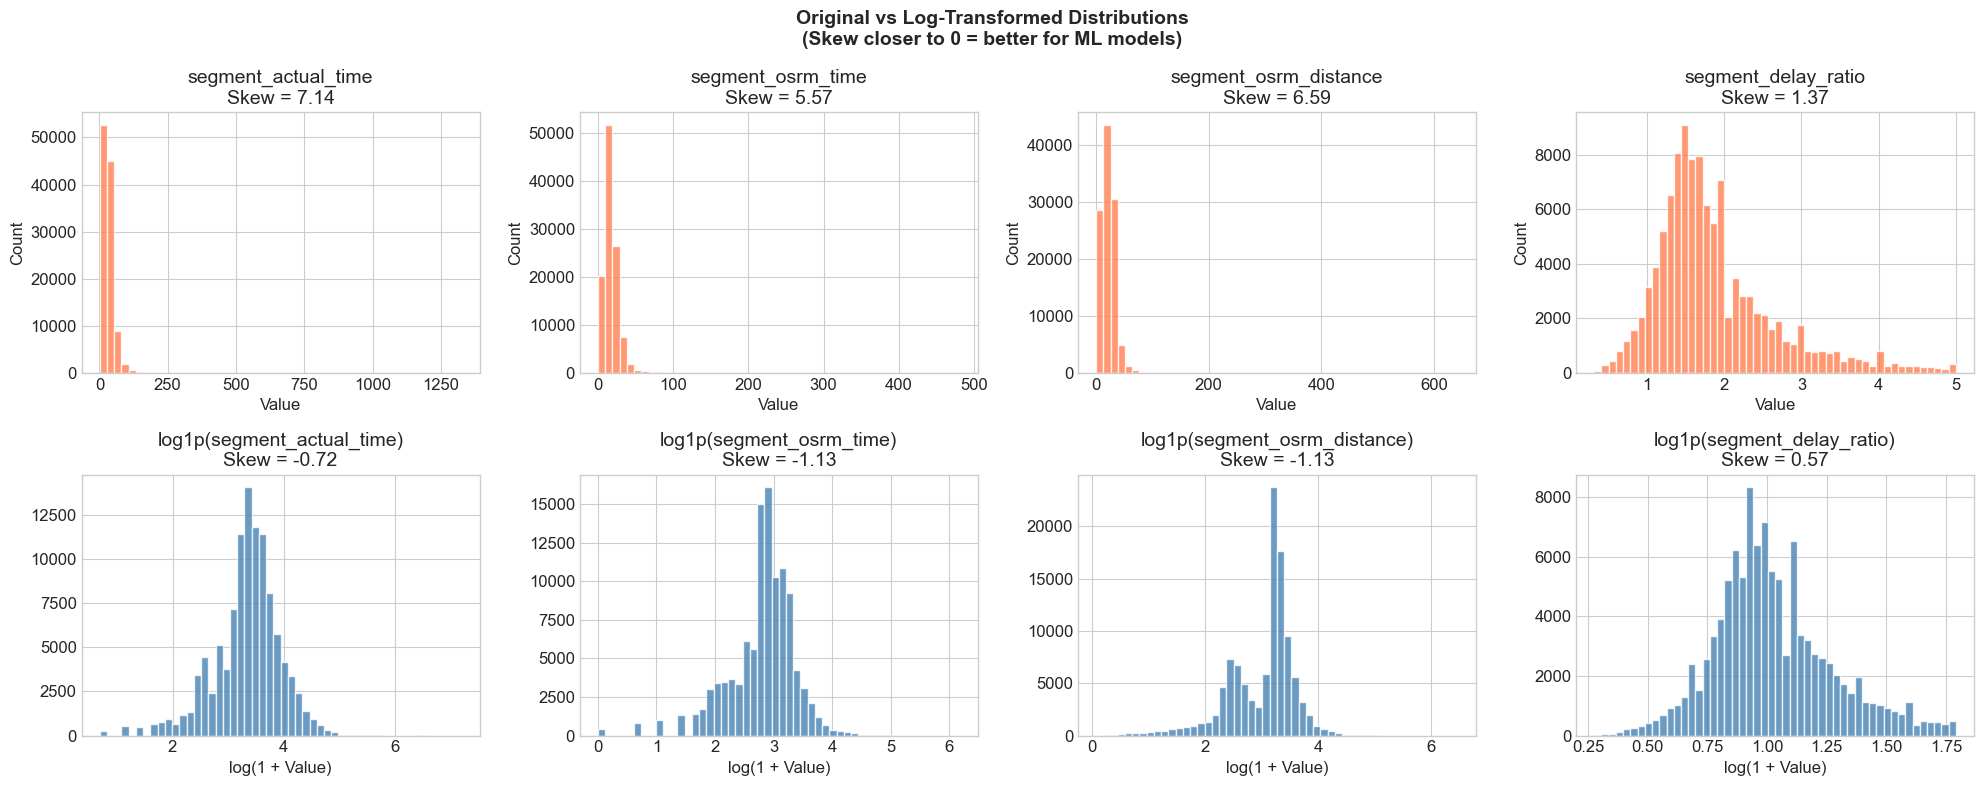


  Column                                Original Skew     After log1p   Needs Log?
  ───────────────────────────────────────────────────────────────────────────
  segment_actual_time                           7.137          -0.724          YES
  segment_osrm_time                             5.571          -1.129          YES
  segment_osrm_distance                         6.591          -1.132          YES
  segment_delay_ratio                           1.365           0.565          YES


In [13]:
#1.11 post- cleaning skewness check

print("=" * 55)
print("  SKEWNESS CHECK — WHY LOG TRANSFORM IS NEEDED")
print("=" * 55)
key_cols = ['segment_actual_time', 'segment_osrm_time','segment_osrm_distance', 'segment_delay_ratio']
 
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
 
for i, col in enumerate(key_cols):
    if col not in df.columns:
        continue
    data    = df[col].dropna()
    sk      = skew(data)
    log_sk  = skew(np.log1p(data))
 
    # Original distribution
    axes[0, i].hist(data, bins=50, color='coral', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\nSkew = {sk:.2f}')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Count')
 
    # Log-transformed distribution
    axes[1, i].hist(np.log1p(data), bins=50,color='steelblue', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'log1p({col})\nSkew = {log_sk:.2f}')
    axes[1, i].set_xlabel('log(1 + Value)')
 
plt.suptitle('Original vs Log-Transformed Distributions\n'
             '(Skew closer to 0 = better for ML models)',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('skewness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print the numbers
print(f"\n  {'Column':<35} {'Original Skew':>15} {'After log1p':>15} {'Needs Log?':>12}")
print(f"  {'─'*75}")
for col in key_cols:
    if col in df.columns:
        orig_sk = skew(df[col].dropna())
        log_sk  = skew(np.log1p(df[col].dropna()))
        needs   = "YES" if abs(orig_sk) > 1 else " No"
        print(f"  {col:<35} {orig_sk:>15.3f} {log_sk:>15.3f} {needs:>12}")


In [14]:
#1.12 saving clean_dataset
df.to_csv('delivery_data_clean_v2.csv', index=False)
 
# Final verification
final_missing = df.isnull().sum().sum()
print("=" * 55)
print(" PHASE 1 COMPLETE")
print("=" * 55)
print(f"  Clean file saved  : delivery_data_clean_v2.csv")
print(f"  Final shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Missing values    : {final_missing}")
print(f"  Training rows     : {(df['data']=='training').sum():,}")
print(f"  Test rows         : {(df['data']=='test').sum():,}")
print(f"  Memory usage      : {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print()
print("  Columns available for Phase 2:")
print(f"  {list(df.columns)}")
print("=" * 55)

 PHASE 1 COMPLETE
  Clean file saved  : delivery_data_clean_v2.csv
  Final shape       : 109,408 rows × 30 columns
  Missing values    : 0
  Training rows     : 79,413
  Test rows         : 29,995
  Memory usage      : 77.7 MB

  Columns available for Phase 2:
  ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'cutoff_hour', 'cutoff_dayofweek', 'cutoff_month', 'is_weekend', 'is_peak_hour', 'segment_delay_ratio']


In [15]:
df = reduce_memory(df)

  Memory: 77.7 MB → 77.3 MB (saved 0.4 MB, 0.5%)


## PHASE 2 — FEATURE ENGINEERING

In [22]:
# 2.1 – Setup & Load Clean Data

# Load the cleaned dataset 
df = pd.read_csv('delivery_data_clean_v2.csv')

# Ensure numeric dtypes are correct (they were saved as strings sometimes)
for col in df.select_dtypes(include='object').columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

print(f"Shape: {df.shape}")
print(f"Training rows: {(df['data']=='training').sum()}")
print(f"Test rows: {(df['data']=='test').sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")

Shape: (109408, 30)
Training rows: 79413
Test rows: 29995
Missing values : 0


In [24]:
#2.1 TRAIN / TEST SPLIT 
#      All leak-free features must be computed ONLY from
#      df_train and then APPLIED to df_test.
df_train = df[df['data'] == 'training'].copy().reset_index(drop=True)
df_test  = df[df['data'] == 'test'].copy().reset_index(drop=True)
 
print(f"Train : {len(df_train):,} rows")
print(f"Test  : {len(df_test):,} rows")
 
assert set(df_train['data'].unique()) == {'training'}
assert set(df_test['data'].unique())  == {'test'}


Train : 79,413 rows
Test  : 29,995 rows


In [25]:
# 2.2 ANALYSIS COLUMNS:CORE DELAY FEATURES
def add_core_delay_features(df):
 
    # Delay ratio (recompute to ensure accuracy)
    df['segment_delay_ratio'] = (
        df['segment_actual_time'] / (df['segment_osrm_time'] + 1e-6)
    ).clip(0, 5)
 
    # Is this segment chronically delayed? (>20% over OSRM)
    df['is_delayed'] = (df['segment_delay_ratio'] > 1.2).astype(np.int8)
 
    # Delay in absolute minutes (negative = arrived early)
    df['delay_minutes'] = (
        df['segment_actual_time'] - df['segment_osrm_time']
    )
 
    # Excess delay (only the overrun — for SLA breach calculation)
    df['excess_delay'] = df['delay_minutes'].clip(lower=0)
 
    # OSRM percentage error
    df['osrm_error_pct'] = (
        (df['segment_actual_time'] - df['segment_osrm_time'])
        / (df['segment_osrm_time'] + 1e-6) * 100
    )
 
    return df
 
df = add_core_delay_features(df)
print("Core delay features added")
print(df[['segment_delay_ratio', 'is_delayed',
          'delay_minutes', 'excess_delay']].describe().round(2))
 

Core delay features added
       segment_delay_ratio  is_delayed  delay_minutes  excess_delay
count          109408.0000 109408.0000    109408.0000   109408.0000
mean                1.8900      0.8600        13.7600       14.1600
std                 0.8100      0.3500        15.5400       14.9800
min                 0.3200      0.0000       -53.0000        0.0000
25%                 1.3700      1.0000         5.0000        5.0000
50%                 1.6900      1.0000        10.0000       10.0000
75%                 2.2000      1.0000        18.0000       18.0000
max                 5.0000      1.0000       872.0000      872.0000


In [26]:
# 2.3 – LOG + SQRT TRANSFORMS
def add_transformed_features(df):
 
    df['log_osrm_time']     = np.log1p(df['segment_osrm_time'])
    df['log_osrm_distance'] = np.log1p(df['segment_osrm_distance'])
    df['log_actual_dist']   = np.log1p(df['actual_distance_to_destination'])
 
    df['sqrt_osrm_time']     = np.sqrt(df['segment_osrm_time'])
    df['sqrt_osrm_distance'] = np.sqrt(df['segment_osrm_distance'])
 
    return df
 
df = add_transformed_features(df)
 
# Compare skewness
print("\n  Transform comparison (skew closer to 0 = better):")
print(f"  {'Column':<28} {'Original':>10} {'log1p':>10} {'sqrt':>10}")
print("  " + "-"*60)
for orig, log_col, sqrt_col in [
    ('segment_osrm_time',     'log_osrm_time',     'sqrt_osrm_time'),
    ('segment_osrm_distance', 'log_osrm_distance', 'sqrt_osrm_distance'),
]:
    s0 = skew(df[orig].dropna())
    s1 = skew(df[log_col].dropna())
    s2 = skew(df[sqrt_col].dropna())
    best = min([(abs(s0),'original'),(abs(s1),'log1p'),(abs(s2),'sqrt')],
               key=lambda x: x[0])[1]
    print(f"  {orig:<28} {s0:>10.2f} {s1:>10.2f} {s2:>10.2f}  best={best}")
 
print(" Log + sqrt features added")


  Transform comparison (skew closer to 0 = better):
  Column                         Original      log1p       sqrt
  ------------------------------------------------------------
  segment_osrm_time                  5.57      -1.13       0.39  best=sqrt
  segment_osrm_distance              6.59      -1.13       0.13  best=sqrt
 Log + sqrt features added


In [27]:
#2.4 – SPEED & EFFICIENCY
def add_speed_features(df):
 
    # OSRM assumed speed (km/h) — what OSRM thinks speed should be
    df['osrm_speed_kmh'] = (
        df['segment_osrm_distance'] /
        (df['segment_osrm_time'] / 60 + 1e-6)
    ).clip(0, 200)
 
    # Actual speed (km/h)
    df['actual_speed_kmh'] = (
        df['segment_osrm_distance'] /
        (df['segment_actual_time'] / 60 + 1e-6)
    ).clip(0, 200)
 
    # Speed ratio: <1 = slower than OSRM expected (congestion)
    df['speed_ratio'] = (
        df['actual_speed_kmh'] / (df['osrm_speed_kmh'] + 1e-6)
    ).clip(0, 5)
 
    # Detour factor: actual distance / planned distance
    # >1 = truck took longer route than planned
    df['detour_factor'] = (
        df['actual_distance_to_destination'] /
        (df['osrm_distance'] + 1e-6)
    ).clip(0, 5)
 
    # Distance efficiency: km per minute
    df['km_per_minute'] = (
        df['segment_osrm_distance'] /
        (df['segment_osrm_time'] + 1e-6)
    )
 
    return df
 
df = add_speed_features(df)




In [28]:
# 2.5 CIRCULAR TIME ENCODING
def add_circular_time_features(df):
 
    df['hour_sin']  = np.sin(2 * np.pi * df['cutoff_hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['cutoff_hour'] / 24)
    df['day_sin']   = np.sin(2 * np.pi * df['cutoff_dayofweek'] / 7)
    df['day_cos']   = np.cos(2 * np.pi * df['cutoff_dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['cutoff_month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['cutoff_month'] / 12)
 
    # OD start time circular (minutes in a day = 0-1440)
    df['od_start_sin'] = np.sin(
        2 * np.pi * (df['od_start_time'] % 1440) / 1440
    )
    df['od_start_cos'] = np.cos(
        2 * np.pi * (df['od_start_time'] % 1440) / 1440
    )
 
    return df
 
df = add_circular_time_features(df)
 


In [29]:
#2.6 CATEGORICAL FEATURES
def add_categorical_features(df):
 
    # Route type binary
    df['route_type_enc'] = (df['route_type'] == 'FTL').astype(np.int8)
 
    # Extract state from 'City_Code (State)' format
    def extract_state(s):
        if pd.isna(s) or s == 'Unknown':
            return 'Unknown'
        try:
            return s.split('(')[-1].replace(')', '').strip()
        except Exception:
            return 'Unknown'
 
    df['source_state'] = df['source_name'].apply(extract_state)
    df['dest_state']   = df['destination_name'].apply(extract_state)
    df['is_interstate'] = (
        df['source_state'] != df['dest_state']
    ).astype(np.int8)
    df['state_pair'] = df['source_state'] + '_TO_' + df['dest_state']
 
    # Time period (for EDA and dashboard readability)
    def time_period(h):
        if h < 6:  return 'Night'
        if h < 12: return 'Morning'
        if h < 18: return 'Afternoon'
        return 'Evening'
 
    df['time_period']    = df['cutoff_hour'].apply(time_period)
    df['is_peak_hour']   = df['cutoff_hour'].apply(
        lambda h: 1 if (9<=h<=12 or 18<=h<=21) else 0
    ).astype(np.int8)
    df['is_weekend']     = (df['cutoff_dayofweek'] >= 5).astype(np.int8)
    df['is_night_shift'] = (df['cutoff_hour'] < 6).astype(np.int8)
 
    # Distance bin
    df['distance_bin'] = pd.cut(
        df['segment_osrm_distance'],
        bins=[0,50,100,200,500,1000,float('inf')],
        labels=['0-50km','50-100km','100-200km',
                '200-500km','500-1000km','1000km+']
    )
 
    return df
 
df = add_categorical_features(df)
print("Categorical features added")
print(f"\n  Inter-state trips : {df['is_interstate'].mean()*100:.1f}%")
print(f"  Peak hour trips   : {df['is_peak_hour'].mean()*100:.1f}%")
print(f"  Night shift trips : {df['is_night_shift'].mean()*100:.1f}%")


Categorical features added

  Inter-state trips : 54.0%
  Peak hour trips   : 29.3%
  Night shift trips : 32.7%


In [31]:
# 2.7 INTERACTION FEATURES
def add_interaction_features(df):
    required_cols = ['route_type_enc', 'is_peak_hour', 'is_night_shift', 'cutoff_hour',
                     'segment_osrm_distance', 'log_osrm_distance', 'segment_osrm_time',
                     'is_interstate', 'osrm_speed_kmh', 'is_weekend']
    for col in required_cols:
        if col not in df.columns:
            raise KeyError(f"Required column '{col}' missing from DataFrame")

    df['carting_x_peak']  = ((df['route_type_enc'] == 0) & (df['is_peak_hour'] == 1)).astype('int8')
    df['carting_x_night'] = ((df['route_type_enc'] == 0) & (df['is_night_shift'] == 1)).astype('int8')
    df['ftl_x_peak']      = ((df['route_type_enc'] == 1) & (df['is_peak_hour'] == 1)).astype('int8')
    df['route_x_hour']    = df['route_type_enc'] * df['cutoff_hour']

    df['dist_x_route']      = df['segment_osrm_distance'] * df['route_type_enc']
    df['log_dist_x_route']  = df['log_osrm_distance'] * df['route_type_enc']
    df['osrm_time_x_route'] = df['segment_osrm_time'] * df['route_type_enc']

    df['interstate_x_route'] = df['is_interstate'] * df['route_type_enc']
    df['speed_x_peak'] = df['osrm_speed_kmh'] * df['is_peak_hour']
    df['dist_x_peak']  = df['segment_osrm_distance'] * df['is_peak_hour']
    df['osrm_time_x_weekend'] = df['segment_osrm_time'] * df['is_weekend']

    return df

df = add_interaction_features(df)
print("Interaction features added")

Interaction features added


In [32]:
# 2.8 TRIP-LEVEL AGGREGATED FEATURES
def add_trip_level_features(df):
 
    # Total segments per trip (how many hubs does it pass through?)
    trip_agg = (
        df.groupby('trip_uuid')['cutoff_factor']
        .max()
        .reset_index()
        .rename(columns={'cutoff_factor': 'total_segments'})
    )
    df = df.merge(trip_agg, on='trip_uuid', how='left')
 
    # Relative position in trip: 0=start, 1=end
    df['segment_position'] = (
        df['cutoff_factor'] / (df['total_segments'] + 1e-6)
    ).clip(0, 1)
 
    # First and last segment flags
    df['is_first_segment'] = (df['cutoff_factor'] == 1).astype(np.int8)
    df['is_last_segment']  = (
        df['cutoff_factor'] == df['total_segments']
    ).astype(np.int8)
 
    # Total OSRM time for the whole trip
    trip_time = (
        df.groupby('trip_uuid')['segment_osrm_time']
        .sum()
        .reset_index()
        .rename(columns={'segment_osrm_time': 'trip_total_osrm'})
    )
    df = df.merge(trip_time, on='trip_uuid', how='left')
 
    # What fraction of total trip time is this segment?
    df['segment_time_fraction'] = (
        df['segment_osrm_time'] / (df['trip_total_osrm'] + 1e-6)
    ).clip(0, 1)
 
    # Fix start_scan_to_end_scan nulls
    # (fill by route_type group median — it was partially null)
    df['start_scan_to_end_scan'] = df['start_scan_to_end_scan'].fillna(
        df.groupby('route_type')['start_scan_to_end_scan']
        .transform('median')
    )
 
    return df
 
df = add_trip_level_features(df)
print("Trip-level features added")
print(f"\n  total_segments distribution:")
print(df['total_segments'].value_counts().head(6).to_string())
print(f"\n  is_first_segment : {df['is_first_segment'].mean()*100:.1f}%")
print(f"  is_last_segment  : {df['is_last_segment'].mean()*100:.1f}%")
 

Trip-level features added

  total_segments distribution:
total_segments
1689    3598
1078    2846
27      1642
36      1550
1694    1474
1690    1402

  is_first_segment : 0.0%
  is_last_segment  : 13.4%


In [33]:
# 2.9 CORRIDOR-LEVEL STATISTICS
print("Computing corridor statistics from training data only...")
 
df_train = df[df['data'] == 'training'].copy().reset_index(drop=True)
df_test  = df[df['data'] == 'test'].copy().reset_index(drop=True)
 
CORR_COLS = ['source_center', 'destination_center', 'route_type']
 
corr_stats = (
    df_train
    .groupby(CORR_COLS)['segment_delay_ratio']
    .agg(
        corridor_median_delay = 'median',
        corridor_mean_delay   = 'mean',
        corridor_std_delay    = 'std',
        corridor_p25_delay    = lambda x: x.quantile(0.25),
        corridor_p75_delay    = lambda x: x.quantile(0.75),
        corridor_max_delay    = 'max',
        corridor_trip_count   = 'count',
    )
    .reset_index()
)
corr_stats['corridor_std_delay']  = corr_stats['corridor_std_delay'].fillna(0)
corr_stats['corridor_iqr_delay']  = (
    corr_stats['corridor_p75_delay'] - corr_stats['corridor_p25_delay']
)
corr_stats['corridor_is_chronic'] = (
    corr_stats['corridor_median_delay'] > 1.2
).astype(np.int8)
 
CORR_STAT_COLS = [
    'corridor_median_delay', 'corridor_mean_delay', 'corridor_std_delay',
    'corridor_p25_delay', 'corridor_p75_delay', 'corridor_max_delay',
    'corridor_trip_count', 'corridor_iqr_delay', 'corridor_is_chronic'
]
 
df_train = df_train.merge(corr_stats, on=CORR_COLS, how='left')
df_test  = df_test.merge(corr_stats, on=CORR_COLS, how='left')
 
# Fill unseen corridors with training medians
fill_vals = corr_stats[CORR_STAT_COLS].median()
for col in CORR_STAT_COLS:
    df_train[col] = df_train[col].fillna(fill_vals[col])
    df_test[col]  = df_test[col].fillna(fill_vals[col])
 
df = pd.concat([df_train, df_test], ignore_index=True)
 
print(f"Corridor statistics added")
print(f"   Unique corridors   : {len(corr_stats):,}")
print(f"   Chronic corridors  : {corr_stats['corridor_is_chronic'].mean()*100:.1f}%")
 

Computing corridor statistics from training data only...
Corridor statistics added
   Unique corridors   : 2,406
   Chronic corridors  : 92.9%


In [34]:
#2.10 HUB-LEVEL FEATURES
print("Computing hub statistics from training data only")
 
df_train = df[df['data'] == 'training'].copy().reset_index(drop=True)
df_test  = df[df['data'] == 'test'].copy().reset_index(drop=True)
 
# Source hub statistics
src_stats = (
    df_train.groupby('source_center')['segment_delay_ratio']
    .agg(
        src_hub_median_delay = 'median',
        src_hub_mean_delay   = 'mean',
        src_hub_std_delay    = 'std',
        src_hub_trip_volume  = 'count',
    )
    .reset_index()
)
src_stats['src_hub_std_delay'] = src_stats['src_hub_std_delay'].fillna(0)
 
# Destination hub statistics
dst_stats = (
    df_train.groupby('destination_center')['segment_delay_ratio']
    .agg(
        dst_hub_median_delay = 'median',
        dst_hub_mean_delay   = 'mean',
        dst_hub_std_delay    = 'std',
        dst_hub_trip_volume  = 'count',
    )
    .reset_index()
)
dst_stats['dst_hub_std_delay'] = dst_stats['dst_hub_std_delay'].fillna(0)
 
for split in [df_train, df_test]:
    for col in ['src_hub_median_delay','src_hub_mean_delay',
                'src_hub_std_delay','src_hub_trip_volume',
                'dst_hub_median_delay','dst_hub_mean_delay',
                'dst_hub_std_delay','dst_hub_trip_volume',
                'hub_delay_diff']:
        if col in split.columns:
            split.drop(columns=[col], inplace=True)
 
df_train = df_train.merge(src_stats, on='source_center', how='left')
df_train = df_train.merge(dst_stats, on='destination_center', how='left')
df_test  = df_test.merge(src_stats, on='source_center', how='left')
df_test  = df_test.merge(dst_stats, on='destination_center', how='left')
 
HUB_COLS = ['src_hub_median_delay','src_hub_mean_delay',
            'src_hub_std_delay','src_hub_trip_volume',
            'dst_hub_median_delay','dst_hub_mean_delay',
            'dst_hub_std_delay','dst_hub_trip_volume']
 
src_fill = src_stats.median(numeric_only=True).to_dict()
dst_fill = dst_stats.median(numeric_only=True).to_dict()
all_fill = {**src_fill, **dst_fill}
 
for col in HUB_COLS:
    df_train[col] = df_train[col].fillna(all_fill.get(col, 0))
    df_test[col]  = df_test[col].fillna(all_fill.get(col, 0))
 
# Hub delay differential (source vs destination quality gap)
df_train['hub_delay_diff'] = (
    df_train['src_hub_median_delay'] - df_train['dst_hub_median_delay']
)
df_test['hub_delay_diff'] = (
    df_test['src_hub_median_delay'] - df_test['dst_hub_median_delay']
)
 
df = pd.concat([df_train, df_test], ignore_index=True)
print(f" Hub-level features added")
print(f"   Unique source hubs : {src_stats.shape[0]:,}")
print(f"   Unique dest hubs   : {dst_stats.shape[0]:,}")
 

Computing hub statistics from training data only
 Hub-level features added
   Unique source hubs : 1,366
   Unique dest hubs   : 1,377


In [35]:
# 2.11 STATE-LEVEL ENCODING
print("Computing state encoding from training data only...")

df_train = df[df['data'] == 'training'].copy().reset_index(drop=True)
df_test  = df[df['data'] == 'test'].copy().reset_index(drop=True)

overall_median = df_train['segment_delay_ratio'].median()

src_state = df_train.groupby('source_state')['segment_delay_ratio'].agg(
    src_state_median_delay='median', src_state_mean_delay='mean'
).reset_index()
dst_state = df_train.groupby('dest_state')['segment_delay_ratio'].agg(
    dst_state_median_delay='median', dst_state_mean_delay='mean'
).reset_index()
pair_delay = df_train.groupby('state_pair')['segment_delay_ratio'].agg(
    state_pair_median_delay='median', state_pair_count='count'
).reset_index()
pair_delay = pair_delay[pair_delay['state_pair_count'] >= 10]

STATE_ENC_COLS = ['src_state_median_delay', 'src_state_mean_delay',
                  'dst_state_median_delay', 'dst_state_mean_delay',
                  'state_pair_median_delay']

for split in [df_train, df_test]:
    for col in STATE_ENC_COLS:
        if col in split.columns:
            split.drop(columns=[col], inplace=True)

df_train = df_train.merge(src_state, on='source_state', how='left')
df_train = df_train.merge(dst_state, on='dest_state', how='left')
df_train = df_train.merge(pair_delay[['state_pair','state_pair_median_delay']], on='state_pair', how='left')
df_test  = df_test.merge(src_state, on='source_state', how='left')
df_test  = df_test.merge(dst_state, on='dest_state', how='left')
df_test  = df_test.merge(pair_delay[['state_pair','state_pair_median_delay']], on='state_pair', how='left')

for col in STATE_ENC_COLS:
    df_train[col] = df_train[col].fillna(overall_median)
    df_test[col]  = df_test[col].fillna(overall_median)

df = pd.concat([df_train, df_test], ignore_index=True)
print("State encoding added")

Computing state encoding from training data only...
State encoding added


In [36]:
print("State encoding added")
print("\n  Top 5 worst source states:")
print(src_state.nlargest(5, 'src_state_median_delay')[
    ['source_state','src_state_median_delay']
].to_string(index=False))

State encoding added

  Top 5 worst source states:
          source_state  src_state_median_delay
               Mizoram                  4.6250
              Nagaland                  2.8966
Dadra and Nagar Haveli                  2.7500
               Tripura                  2.6810
             Meghalaya                  2.3437


In [37]:
# 2.12 HISTORICAL DELAY (MULTI-LEVEL)
print("Computing leak-free historical delay (3 levels)...")

df_train = df[df['data'] == 'training'].copy().reset_index(drop=True)
df_test  = df[df['data'] == 'test'].copy().reset_index(drop=True)

overall_median = df_train['segment_delay_ratio'].median()

rt_delay = df_train.groupby('route_type')['segment_delay_ratio'].mean().reset_index().rename(columns={'segment_delay_ratio': 'rt_avg_delay'})
corr_delay = df_train.groupby(['source_center','destination_center','route_type'])['segment_delay_ratio'].mean().reset_index().rename(columns={'segment_delay_ratio': 'hist_corridor_delay'})
corr_hour_delay = df_train.groupby(['source_center','destination_center','route_type','cutoff_hour'])['segment_delay_ratio'].mean().reset_index().rename(columns={'segment_delay_ratio': 'hist_corridor_hour_delay'})

HIST_COLS = ['rt_avg_delay', 'hist_corridor_delay', 'hist_corridor_hour_delay']
for split in [df_train, df_test]:
    for col in HIST_COLS:
        if col in split.columns:
            split.drop(columns=[col], inplace=True)

df_train = df_train.merge(rt_delay, on='route_type', how='left')
df_train = df_train.merge(corr_delay, on=['source_center','destination_center','route_type'], how='left')
df_train = df_train.merge(corr_hour_delay, on=['source_center','destination_center','route_type','cutoff_hour'], how='left')
df_test  = df_test.merge(rt_delay, on='route_type', how='left')
df_test  = df_test.merge(corr_delay, on=['source_center','destination_center','route_type'], how='left')
df_test  = df_test.merge(corr_hour_delay, on=['source_center','destination_center','route_type','cutoff_hour'], how='left')

for split in [df_train, df_test]:
    split['rt_avg_delay']              = split['rt_avg_delay'].fillna(overall_median)
    split['hist_corridor_delay']       = split['hist_corridor_delay'].fillna(split['rt_avg_delay'])
    split['hist_corridor_hour_delay']  = split['hist_corridor_hour_delay'].fillna(split['hist_corridor_delay'])

df = pd.concat([df_train, df_test], ignore_index=True)
print("Historical delay features added (3 levels)")

Computing leak-free historical delay (3 levels)...
Historical delay features added (3 levels)


In [38]:
# 2.13 FINAL SPLIT AND TARGET PREPARATION
df_train = df[df['data'] == 'training'].copy().reset_index(drop=True)
df_test  = df[df['data'] == 'test'].copy().reset_index(drop=True)
 
TARGET = 'segment_actual_time'
 
y_train      = df_train[TARGET].astype(np.float32)
y_test       = df_test[TARGET].astype(np.float32)
y_train_log  = np.log1p(y_train)
y_test_log   = np.log1p(y_test)
y_train_sqrt = np.sqrt(y_train)
y_test_sqrt  = np.sqrt(y_test)
 
# Pick best transform (skew closest to 0)
transforms = {
    'original': skew(y_train),
    'log1p'   : skew(y_train_log),
    'sqrt'    : skew(y_train_sqrt),
}
best_transform = min(transforms, key=lambda k: abs(transforms[k]))
 
print("Target transform comparison:")
for name, sk in transforms.items():
    marker = " <- USE THIS" if name == best_transform else ""
    print(f"  {name:<10}: skew = {sk:>7.3f}{marker}")
 

Target transform comparison:
  original  : skew =   1.623
  log1p     : skew =  -0.767
  sqrt      : skew =   0.423 <- USE THIS


In [39]:
# 2.14 DEFINE MODEL FEATURE LISTS (excludes all analysis columns)
BASELINE_FEATURES = [
    # Raw OSRM
    'segment_osrm_time', 'segment_osrm_distance',
    # Transformed
    'log_osrm_time', 'log_osrm_distance', 'sqrt_osrm_time', 'sqrt_osrm_distance',
    # Speed (OSRM only)
    'osrm_speed_kmh', 'km_per_minute',
    # Route type
    'route_type_enc',
    # Time
    'cutoff_hour', 'cutoff_dayofweek', 'cutoff_month',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
    'od_start_sin', 'od_start_cos',
    # Time flags
    'is_peak_hour', 'is_weekend', 'is_night_shift',
    # Geographic
    'is_interstate',
    # Scan time
    'start_scan_to_end_scan',
    # Trip position
    'cutoff_factor', 'total_segments', 'segment_position',
    'is_last_segment', 'is_first_segment', 'segment_time_fraction', 'trip_total_osrm',
    # Historical stats (leak‑free)
    'rt_avg_delay', 'hist_corridor_delay', 'hist_corridor_hour_delay',
    # Corridor stats
    'corridor_median_delay', 'corridor_mean_delay', 'corridor_std_delay',
    'corridor_p75_delay', 'corridor_trip_count', 'corridor_iqr_delay', 'corridor_is_chronic',
    # Hub stats
    'src_hub_median_delay', 'src_hub_std_delay', 'src_hub_trip_volume',
    'dst_hub_median_delay', 'dst_hub_std_delay', 'dst_hub_trip_volume', 'hub_delay_diff',
    # State encoding
    'src_state_median_delay', 'dst_state_median_delay', 'state_pair_median_delay',
    # Interactions
    'carting_x_peak', 'carting_x_night', 'ftl_x_peak', 'route_x_hour',
    'dist_x_route', 'log_dist_x_route', 'osrm_time_x_route', 'interstate_x_route',
    'speed_x_peak', 'dist_x_peak', 'osrm_time_x_weekend',
]

# Ensure only existing columns
BASELINE_FEATURES = [f for f in BASELINE_FEATURES if f in df.columns]

# Graph features (to be added in Phase 4)
EMB_COLS_SRC      = [f'src_emb_{i}' for i in range(64)]
EMB_COLS_DST      = [f'dst_emb_{i}' for i in range(64)]
GRAPH_METRIC_COLS = [
    'src_betweenness', 'dst_betweenness', 'src_total_degree', 'dst_total_degree',
    'src_clustering', 'dst_clustering', 'src_pagerank', 'dst_pagerank',
    'src_sla_pct', 'dst_sla_pct',
]
GRAPH_FEATURES = BASELINE_FEATURES + EMB_COLS_SRC + EMB_COLS_DST + GRAPH_METRIC_COLS

print(f"\nModel feature lists defined")
print(f"   BASELINE_FEATURES : {len(BASELINE_FEATURES)} (leak‑free)")
print(f"   GRAPH_FEATURES    : {len(GRAPH_FEATURES)}")


Model feature lists defined
   BASELINE_FEATURES : 63 (leak‑free)
   GRAPH_FEATURES    : 201


In [40]:
# BUILD FEATURE MATRICES
fill_median = df_train[BASELINE_FEATURES].median()
 
X_train = df_train[BASELINE_FEATURES].fillna(fill_median).astype(np.float32)
X_test  = df_test[BASELINE_FEATURES].fillna(fill_median).astype(np.float32)
 
assert X_train.isnull().sum().sum() == 0, "NaN found in X_train!"
assert X_test.isnull().sum().sum()  == 0, "NaN found in X_test!"
 
print(f"Feature matrices ready")
print(f"   X_train : {X_train.shape[0]:,} x {X_train.shape[1]}")
print(f"   X_test  : {X_test.shape[0]:,} x {X_test.shape[1]}")

Feature matrices ready
   X_train : 79,413 x 63
   X_test  : 29,995 x 63


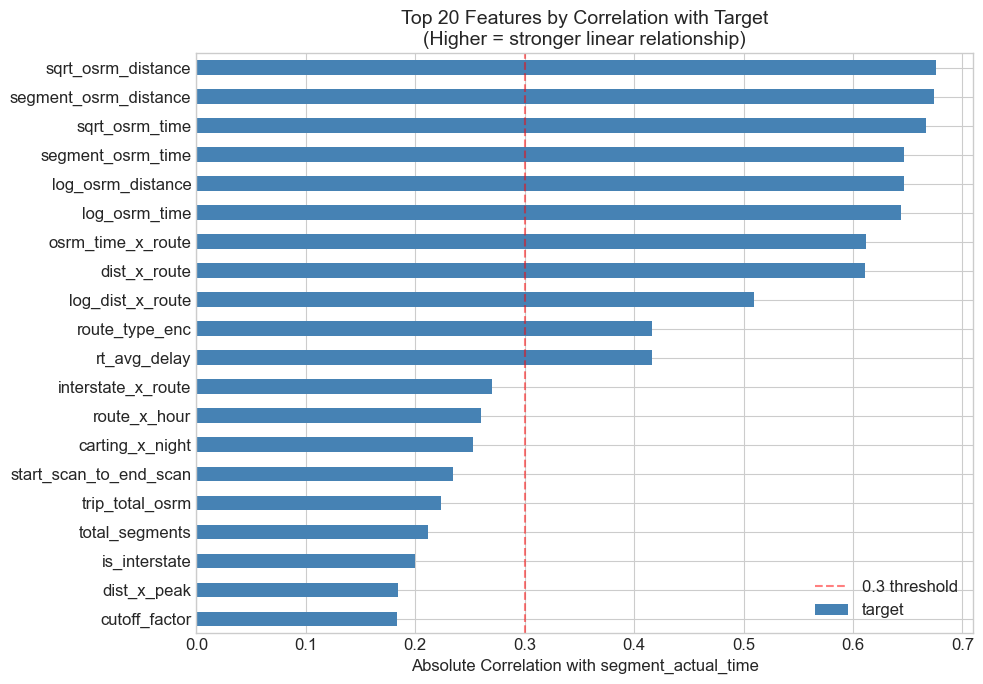

Top 20 features by correlation:
sqrt_osrm_distance       0.6756
segment_osrm_distance    0.6741
sqrt_osrm_time           0.6672
segment_osrm_time        0.6465
log_osrm_distance        0.6463
log_osrm_time            0.6442
osrm_time_x_route        0.6120
dist_x_route             0.6110
log_dist_x_route         0.5099
route_type_enc           0.4165
rt_avg_delay             0.4165
interstate_x_route       0.2701
route_x_hour             0.2597
carting_x_night          0.2524
start_scan_to_end_scan   0.2343
trip_total_osrm          0.2234
total_segments           0.2118
is_interstate            0.1996
dist_x_peak              0.1840
cutoff_factor            0.1838


In [41]:
# FEATURE CORRELATION WITH TARGET (TOP 20)
corr_with_target = (
    X_train.assign(target=y_train.values)
    .corr()['target']
    .drop('target')
    .abs()
    .sort_values(ascending=False)
    .head(20)
)
 
fig, ax = plt.subplots(figsize=(10, 7))
corr_with_target.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Absolute Correlation with segment_actual_time')
ax.set_title('Top 20 Features by Correlation with Target\n'
             '(Higher = stronger linear relationship)')
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='0.3 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=120, bbox_inches='tight')
plt.show()
 
print("Top 20 features by correlation:")
print(corr_with_target.to_string())
 

In [42]:
# 2.17 SAVE EVERYTHING FOR DOWNSTREAM PHASES
# Full dataset (with analysis columns) – for EDA and bottleneck audit
df.to_csv('delivery_features_v2.csv', index=False)

# Train/test splits (also with analysis columns)
df_train.to_csv('df_train_features.csv', index=False)
df_test.to_csv('df_test_features.csv',  index=False)

# Feature lists (model features only)
with open('feature_lists.pkl', 'wb') as f:
    pickle.dump({
        'BASELINE_FEATURES' : BASELINE_FEATURES,
        'GRAPH_FEATURES'    : GRAPH_FEATURES,
        'GRAPH_METRIC_COLS' : GRAPH_METRIC_COLS,
        'EMB_COLS_SRC'      : EMB_COLS_SRC,
        'EMB_COLS_DST'      : EMB_COLS_DST,
    }, f)

# Targets
joblib.dump({
    'y_train'      : y_train,
    'y_test'       : y_test,
    'y_train_log'  : y_train_log,
    'y_test_log'   : y_test_log,
    'y_train_sqrt' : y_train_sqrt,
    'y_test_sqrt'  : y_test_sqrt,
    'best_transform': best_transform,
}, 'targets_v2.pkl')

# Feature matrices (model features only)
joblib.dump({'X_train': X_train, 'X_test': X_test, 'fill_median': fill_median}, 'feature_matrices.pkl')

print("=" * 55)
print("  PHASE 2 COMPLETE")
print("=" * 55)
print(f"  Files saved – all analysis columns retained for EDA/audit.")
print(f"  Model features (safe) : {len(BASELINE_FEATURES)}")
print(f"  Training samples      : {len(X_train):,}")
print(f"  Test samples          : {len(X_test):,}")
print(f"  Best target transform : {best_transform}")
print()

print("=" * 55)

  PHASE 2 COMPLETE
  Files saved – all analysis columns retained for EDA/audit.
  Model features (safe) : 63
  Training samples      : 79,413
  Test samples          : 29,995
  Best target transform : sqrt

  Next: Phase 3 — EDA


In [44]:
df.shape

(109408, 103)

## PHASE 3 — EXPLORATORY DATA ANALYSIS

In [45]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
 
df       = pd.read_csv('delivery_features_v2.csv')
df_train = df[df['data'] == 'training'].copy()
df_test  = df[df['data'] == 'test'].copy()
y_train  = df_train['segment_actual_time']

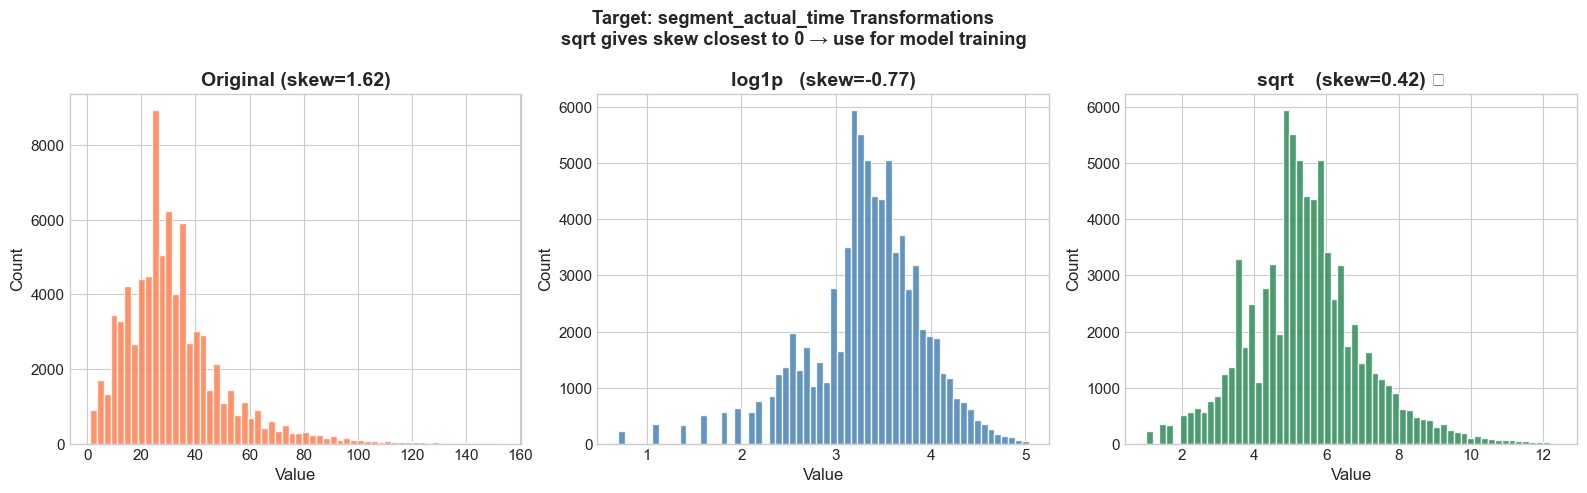

segment_actual_time percentiles (training):
  P50 = 28 min
  P75 = 39 min
  P90 = 55 min
  P95 = 68 min
  P99 = 98 min


In [46]:
# 3.2 – Target Distribution (Why sqrt is best)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (data, title, color) in zip(axes, [
    (y_train,             'Original (skew=1.62)',      'coral'),
    (np.log1p(y_train),   'log1p   (skew=-0.77)',     'steelblue'),
    (np.sqrt(y_train),    'sqrt    (skew=0.42) ✅',    'seagreen'),
]):
    ax.hist(data, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Target: segment_actual_time Transformations\n'
             'sqrt gives skew closest to 0 → use for model training',
             fontweight='bold')
plt.tight_layout()
plt.savefig('eda_target_transforms.png', dpi=130, bbox_inches='tight')
plt.show()

print("segment_actual_time percentiles (training):")
for p in [50, 75, 90, 95, 99]:
    print(f"  P{p:2d} = {y_train.quantile(p/100):.0f} min")

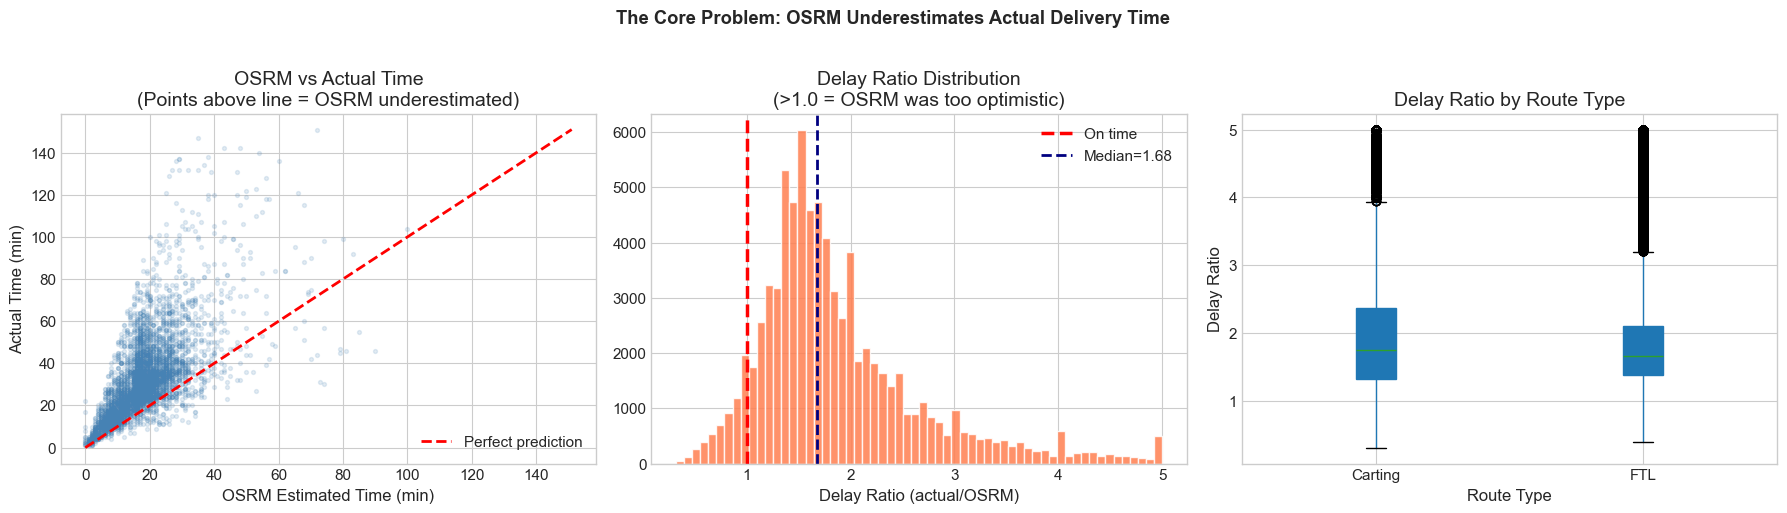

Median delay ratio : 1.679 (68% over OSRM)
Trips delayed >20% : 85.4%
Trips delayed >100%: 29.7%


In [47]:
# 3.3 – OSRM vs Actual & Delay Ratio Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: OSRM predicted vs actual
sample = df_train.sample(5000, random_state=42)
axes[0].scatter(sample['segment_osrm_time'], sample['segment_actual_time'],
                alpha=0.15, s=8, color='steelblue')
max_val = max(sample['segment_osrm_time'].max(), sample['segment_actual_time'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('OSRM Estimated Time (min)')
axes[0].set_ylabel('Actual Time (min)')
axes[0].set_title('OSRM vs Actual Time\n(Points above line = OSRM underestimated)')
axes[0].legend()

# Delay ratio distribution
axes[1].hist(df_train['segment_delay_ratio'], bins=60,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(x=1.0, color='red', lw=2.5, linestyle='--', label='On time')
axes[1].axvline(x=df_train['segment_delay_ratio'].median(),
                color='navy', lw=2, linestyle='--',
                label=f"Median={df_train['segment_delay_ratio'].median():.2f}")
axes[1].set_xlabel('Delay Ratio (actual/OSRM)')
axes[1].set_title('Delay Ratio Distribution\n(>1.0 = OSRM was too optimistic)')
axes[1].legend()

# FTL vs Carting delay ratio boxplot
df_train.boxplot(column='segment_delay_ratio', by='route_type', ax=axes[2],
                 patch_artist=True)
axes[2].set_title('Delay Ratio by Route Type')
axes[2].set_xlabel('Route Type')
axes[2].set_ylabel('Delay Ratio')
plt.sca(axes[2])
plt.title('Delay Ratio by Route Type')
plt.suptitle('')

plt.suptitle('The Core Problem: OSRM Underestimates Actual Delivery Time',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_osrm_vs_actual.png', dpi=130, bbox_inches='tight')
plt.show()

med = df_train['segment_delay_ratio'].median()
pct_late = (df_train['segment_delay_ratio'] > 1.2).mean() * 100
print(f"Median delay ratio : {med:.3f} ({(med-1)*100:.0f}% over OSRM)")
print(f"Trips delayed >20% : {pct_late:.1f}%")
print(f"Trips delayed >100%: {(df_train['segment_delay_ratio']>2.0).mean()*100:.1f}%")

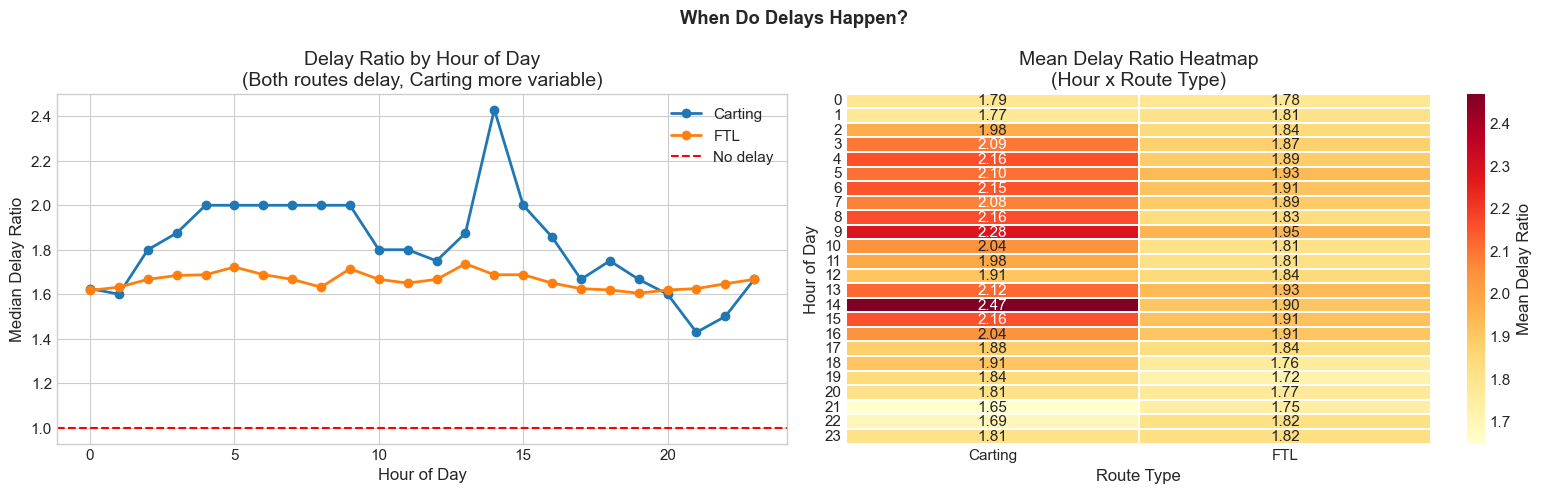


Key finding:
  Carting + Peak    : 1.910
  Carting + NoPeak  : 1.982
Carting off-peak is WORSE than peak — likely night-time depot staffing issues.

  Carting night (0-6h) : 1.970
  Carting day  (6-24h) : 1.961


In [48]:
# 3.4 – Delay by Hour and Route Type
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly median delay by route type
hourly = (df_train
          .groupby(['cutoff_hour', 'route_type'])['segment_delay_ratio']
          .median().unstack())
hourly.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].axhline(y=1.0, color='red', linestyle='--', lw=1.5, label='No delay')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Median Delay Ratio')
axes[0].set_title('Delay Ratio by Hour of Day\n(Both routes delay, Carting more variable)')
axes[0].legend()

# Heatmap: hour x route_type delay
pivot = (df_train
         .groupby(['cutoff_hour', 'route_type'])['segment_delay_ratio']
         .mean().unstack())
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', annot=True,
            fmt='.2f', linewidths=0.3, cbar_kws={'label': 'Mean Delay Ratio'})
axes[1].set_title('Mean Delay Ratio Heatmap\n(Hour x Route Type)')
axes[1].set_xlabel('Route Type')
axes[1].set_ylabel('Hour of Day')

plt.suptitle('When Do Delays Happen?', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_delay_by_hour.png', dpi=130, bbox_inches='tight')
plt.show()

# Key finding: Carting off‑peak vs peak
carting_peak    = df_train[df_train['carting_x_peak']==1]['segment_delay_ratio'].mean()
carting_nopeak  = df_train[(df_train['route_type_enc']==0) & (df_train['is_peak_hour']==0)]['segment_delay_ratio'].mean()
print(f"\nKey finding:")
print(f"  Carting + Peak    : {carting_peak:.3f}")
print(f"  Carting + NoPeak  : {carting_nopeak:.3f}")
if carting_nopeak > carting_peak:
    print("Carting off-peak is WORSE than peak — likely night-time depot staffing issues.")

night_carting = df_train[(df_train['route_type']=='Carting') & (df_train['is_night_shift']==1)]['segment_delay_ratio'].mean()
day_carting   = df_train[(df_train['route_type']=='Carting') & (df_train['is_night_shift']==0)]['segment_delay_ratio'].mean()
print(f"\n  Carting night (0-6h) : {night_carting:.3f}")
print(f"  Carting day  (6-24h) : {day_carting:.3f}")

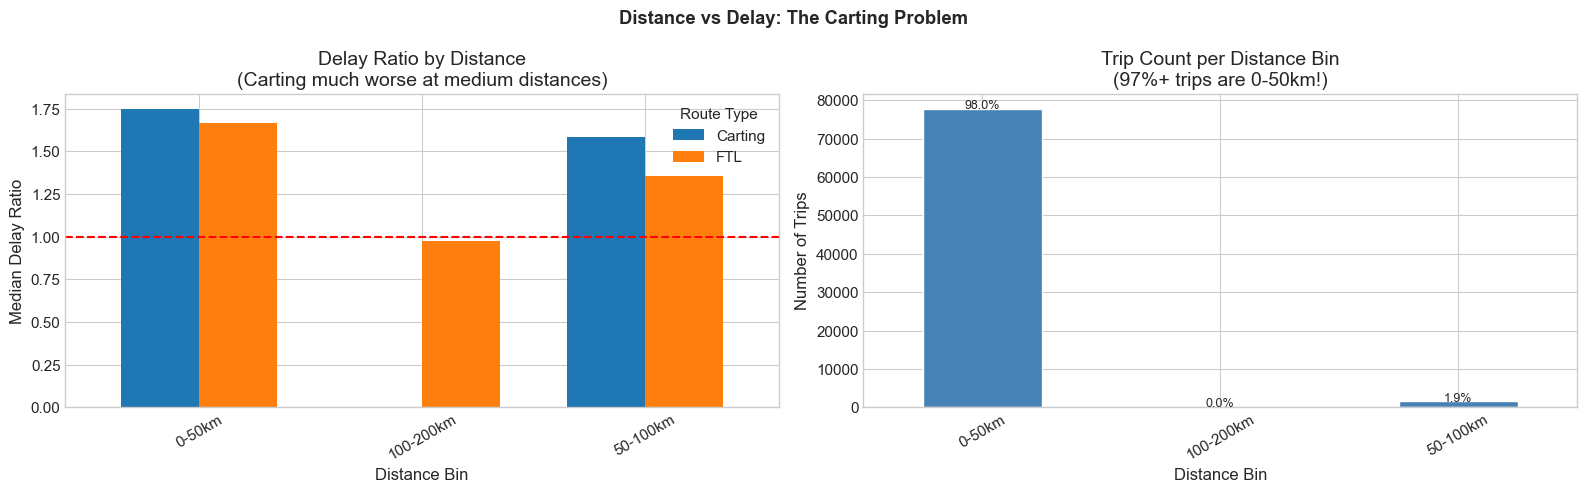

Delay ratio by distance bin and route type:
route_type    Carting    FTL
distance_bin                
0-50km         1.7500 1.6670
100-200km         NaN 0.9730
50-100km       1.5850 1.3550


In [49]:
# 3.5 – Delay by Distance Bin
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dist_delay = (df_train
              .groupby(['distance_bin', 'route_type'])['segment_delay_ratio']
              .median().unstack())
dist_delay.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].axhline(y=1.0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Distance Bin')
axes[0].set_ylabel('Median Delay Ratio')
axes[0].set_title('Delay Ratio by Distance\n(Carting much worse at medium distances)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Route Type')

# Trip count per distance bin
trip_counts = df_train['distance_bin'].value_counts().sort_index()
trip_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Distance Bin')
axes[1].set_ylabel('Number of Trips')
axes[1].set_title('Trip Count per Distance Bin\n(97%+ trips are 0-50km!)')
axes[1].tick_params(axis='x', rotation=30)
for i, (idx, val) in enumerate(trip_counts.items()):
    axes[1].text(i, val + 100, f'{val/len(df_train)*100:.1f}%',
                 ha='center', fontsize=9)

plt.suptitle('Distance vs Delay: The Carting Problem', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_delay_by_distance.png', dpi=130, bbox_inches='tight')
plt.show()

print("Delay ratio by distance bin and route type:")
print(dist_delay.round(3).to_string())

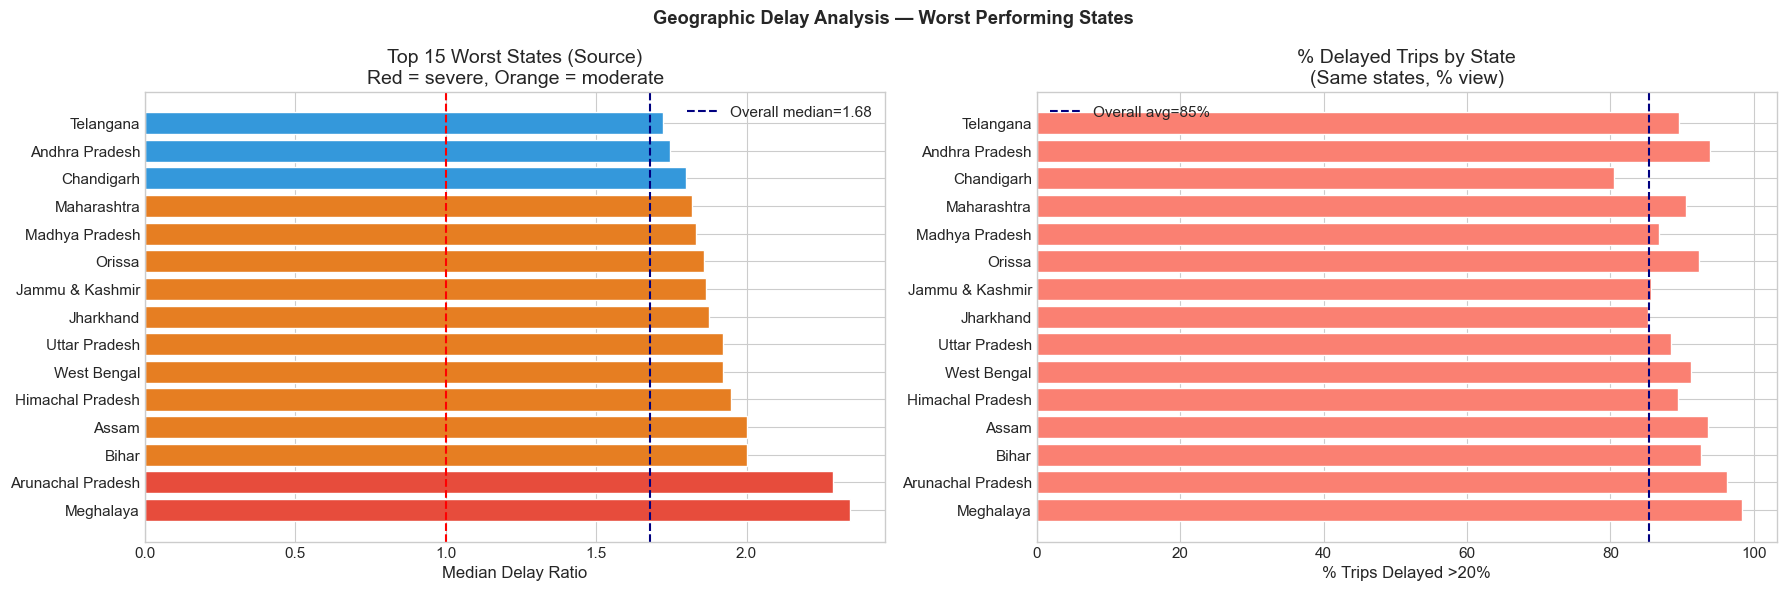

Top 10 worst states:
                   trips  median_delay  pct_delayed
source_state                                       
Meghalaya             59        2.3440       0.9830
Arunachal Pradesh    105        2.2860       0.9620
Bihar               1702        2.0000       0.9270
Assam               1696        2.0000       0.9360
Himachal Pradesh     236        1.9480       0.8940
West Bengal         2914        1.9230       0.9130
Uttar Pradesh       2717        1.9230       0.8840
Jharkhand           1319        1.8750       0.8530
Jammu & Kashmir       77        1.8670       0.8570
Orissa               718        1.8570       0.9230


In [50]:
# 3.6 – Geographic Analysis (Worst States)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

state_stats = (df_train
               .groupby('source_state')
               .agg(trips=('segment_delay_ratio','count'),
                    median_delay=('segment_delay_ratio','median'),
                    pct_delayed=('is_delayed','mean'))
               .query('trips >= 50')
               .sort_values('median_delay', ascending=False))

# Top 15 worst states
top15 = state_stats.head(15)
axes[0].barh(top15.index, top15['median_delay'],
             color=['#e74c3c' if x > 2.0 else '#e67e22' if x > 1.8 else '#3498db'
                    for x in top15['median_delay']],
             edgecolor='white')
axes[0].axvline(x=1.0, color='red', linestyle='--', lw=1.5)
axes[0].axvline(x=df_train['segment_delay_ratio'].median(),
                color='navy', linestyle='--', lw=1.5,
                label=f"Overall median={df_train['segment_delay_ratio'].median():.2f}")
axes[0].set_xlabel('Median Delay Ratio')
axes[0].set_title('Top 15 Worst States (Source)\nRed = severe, Orange = moderate')
axes[0].legend()

# % trips delayed per state
axes[1].barh(top15.index, top15['pct_delayed'] * 100,
             color='salmon', edgecolor='white')
axes[1].axvline(x=df_train['is_delayed'].mean()*100, color='navy',
                linestyle='--', lw=1.5,
                label=f"Overall avg={df_train['is_delayed'].mean()*100:.0f}%")
axes[1].set_xlabel('% Trips Delayed >20%')
axes[1].set_title('% Delayed Trips by State\n(Same states, % view)')
axes[1].legend()

plt.suptitle('Geographic Delay Analysis — Worst Performing States',
             fontweight='bold')
plt.tight_layout()
plt.savefig('eda_geographic.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top 10 worst states:")
print(state_stats.head(10)[['trips','median_delay','pct_delayed']].round(3).to_string())

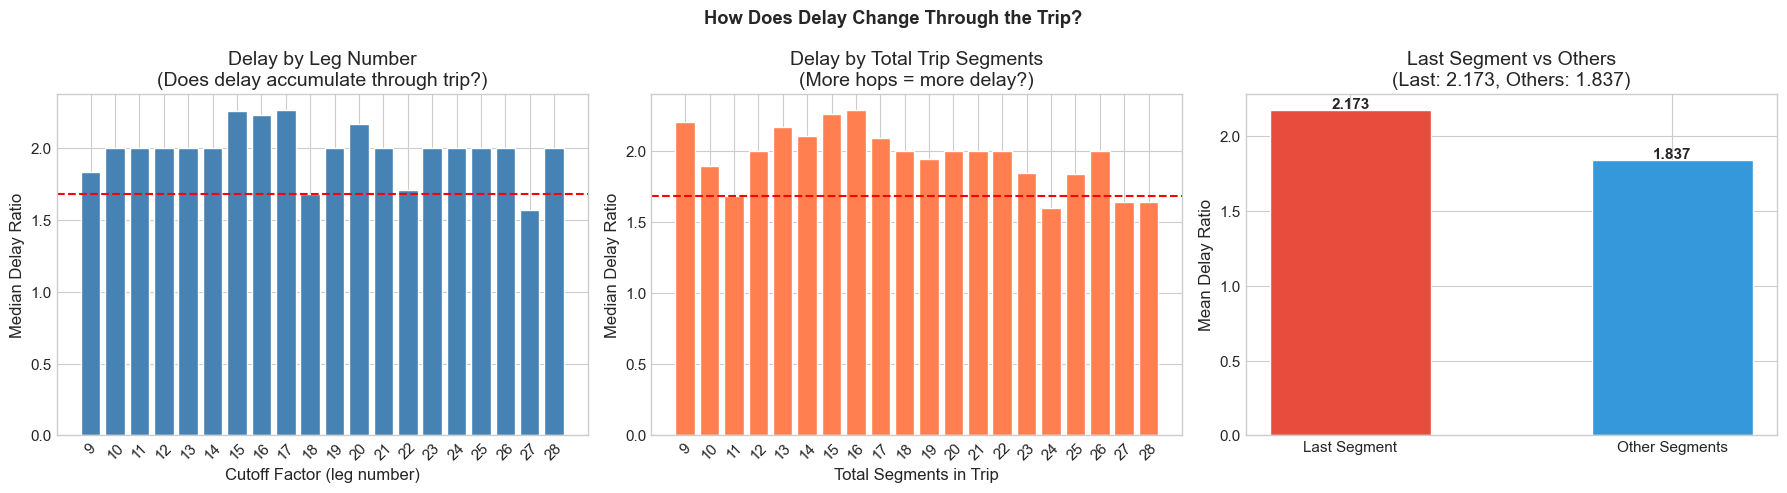

In [51]:
# 3.7 – Trip Position Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Delay by cutoff_factor (leg number)
cf_delay = (df_train.groupby('cutoff_factor')['segment_delay_ratio']
            .agg(['median','count'])
            .query('count >= 30')
            .head(20))
axes[0].bar(cf_delay.index.astype(str), cf_delay['median'],
            color='steelblue', edgecolor='white')
axes[0].axhline(y=df_train['segment_delay_ratio'].median(),
                color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Cutoff Factor (leg number)')
axes[0].set_ylabel('Median Delay Ratio')
axes[0].set_title('Delay by Leg Number\n(Does delay accumulate through trip?)')
axes[0].tick_params(axis='x', rotation=45)

# Total segments vs delay
seg_delay = (df_train.groupby('total_segments')['segment_delay_ratio']
             .agg(['median','count'])
             .query('count >= 30')
             .head(20))
axes[1].bar(seg_delay.index.astype(str), seg_delay['median'],
            color='coral', edgecolor='white')
axes[1].axhline(y=df_train['segment_delay_ratio'].median(),
                color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Total Segments in Trip')
axes[1].set_ylabel('Median Delay Ratio')
axes[1].set_title('Delay by Total Trip Segments\n(More hops = more delay?)')
axes[1].tick_params(axis='x', rotation=45)

# Last vs non-last segment
last_delay    = df_train[df_train['is_last_segment']==1]['segment_delay_ratio'].mean()
nonlast_delay = df_train[df_train['is_last_segment']==0]['segment_delay_ratio'].mean()
axes[2].bar(['Last Segment', 'Other Segments'],
            [last_delay, nonlast_delay],
            color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5)
axes[2].set_ylabel('Mean Delay Ratio')
axes[2].set_title(f'Last Segment vs Others\n(Last: {last_delay:.3f}, Others: {nonlast_delay:.3f})')
for i, v in enumerate([last_delay, nonlast_delay]):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('How Does Delay Change Through the Trip?', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_trip_position.png', dpi=130, bbox_inches='tight')
plt.show()

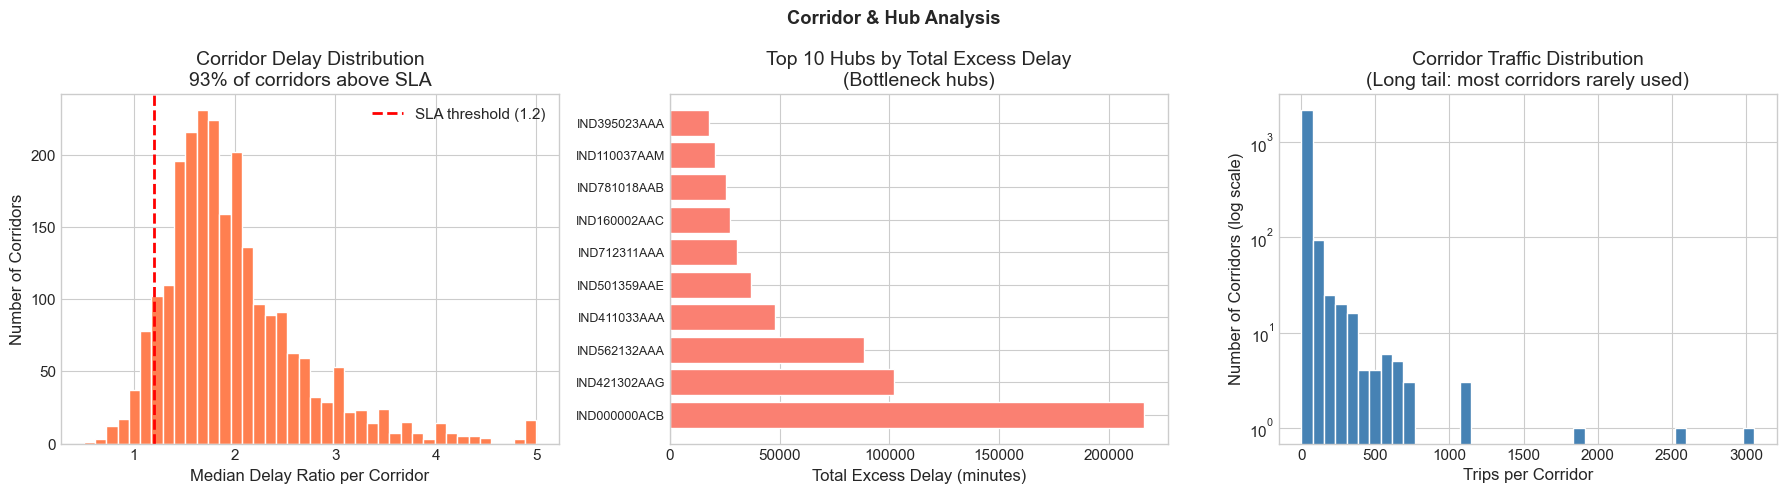

Total corridors         : 2,406
Chronic (>1.2 delay)    : 2,234 (92.9%)
Perfectly on-time (<1.0): 53


In [52]:
# 3.8 – Corridor & Hub Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Corridor delay distribution
corridor_medians = (df_train
                    .groupby(['source_center','destination_center','route_type'])
                    ['segment_delay_ratio'].median())
axes[0].hist(corridor_medians, bins=40, color='coral', edgecolor='white')
axes[0].axvline(x=1.2, color='red', linestyle='--', lw=2,
                label='SLA threshold (1.2)')
axes[0].set_xlabel('Median Delay Ratio per Corridor')
axes[0].set_ylabel('Number of Corridors')
axes[0].set_title(f'Corridor Delay Distribution\n'
                  f'{(corridor_medians>1.2).mean()*100:.0f}% of corridors above SLA')
axes[0].legend()

# Top 10 hubs by total excess delay
hub_breach = (df_train
              .groupby('source_center')['excess_delay']
              .sum()
              .sort_values(ascending=False)
              .head(10))
axes[1].barh(range(len(hub_breach)), hub_breach.values, color='salmon', edgecolor='white')
axes[1].set_yticks(range(len(hub_breach)))
axes[1].set_yticklabels([f"{h[:12]}..." if len(h)>12 else h
                         for h in hub_breach.index], fontsize=9)
axes[1].set_xlabel('Total Excess Delay (minutes)')
axes[1].set_title('Top 10 Hubs by Total Excess Delay\n(Bottleneck hubs)')

# Corridor trip count distribution (long tail)
corridor_counts = df_train.groupby(['source_center','destination_center'])['segment_delay_ratio'].count()
axes[2].hist(corridor_counts, bins=40, color='steelblue', edgecolor='white', log=True)
axes[2].set_xlabel('Trips per Corridor')
axes[2].set_ylabel('Number of Corridors (log scale)')
axes[2].set_title('Corridor Traffic Distribution\n(Long tail: most corridors rarely used)')

plt.suptitle('Corridor & Hub Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_corridors.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Total corridors         : {len(corridor_medians):,}")
print(f"Chronic (>1.2 delay)    : {(corridor_medians>1.2).sum():,} ({(corridor_medians>1.2).mean()*100:.1f}%)")
print(f"Perfectly on-time (<1.0): {(corridor_medians<1.0).sum():,}")

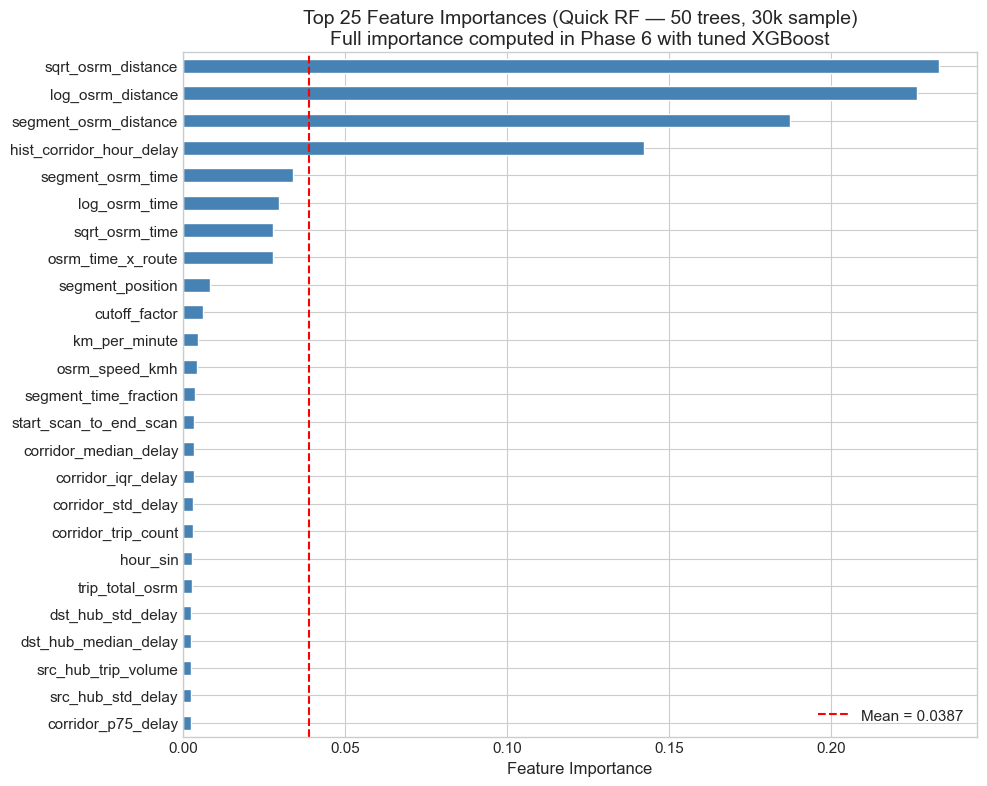

Top 15 features by quick RF importance:
sqrt_osrm_distance         0.2333
log_osrm_distance          0.2263
segment_osrm_distance      0.1871
hist_corridor_hour_delay   0.1422
segment_osrm_time          0.0337
log_osrm_time              0.0296
sqrt_osrm_time             0.0278
osrm_time_x_route          0.0277
segment_position           0.0083
cutoff_factor              0.0061
km_per_minute              0.0044
osrm_speed_kmh             0.0043
segment_time_fraction      0.0037
start_scan_to_end_scan     0.0034
corridor_median_delay      0.0032


In [53]:
# 3.9 – Feature Importance Preview (Quick RF on sample)
feat_lists = joblib.load('feature_lists.pkl')
BASELINE   = feat_lists['BASELINE_FEATURES']

# Use only features that exist in df_train
BASELINE = [f for f in BASELINE if f in df_train.columns]

fill_med = df_train[BASELINE].median()
X_sample = df_train[BASELINE].fillna(fill_med).astype(np.float32)
y_sample = np.sqrt(df_train['segment_actual_time'])  # sqrt target

# Quick RF on 30k sample
idx = np.random.choice(len(X_sample), min(30000, len(X_sample)), replace=False)
rf_quick = RandomForestRegressor(n_estimators=50, max_depth=10,
                                  random_state=42, n_jobs=-1)
rf_quick.fit(X_sample.iloc[idx], y_sample.iloc[idx])

feat_imp = (pd.Series(rf_quick.feature_importances_, index=BASELINE)
            .sort_values(ascending=False)
            .head(25))

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 25 Feature Importances (Quick RF — 50 trees, 30k sample)\n'
             'Full importance computed in Phase 6 with tuned XGBoost')
ax.axvline(x=feat_imp.mean(), color='red', linestyle='--', lw=1.5,
           label=f'Mean = {feat_imp.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('eda_feature_importance_preview.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top 15 features by quick RF importance:")
print(feat_imp.head(15).round(5).to_string())

In [54]:
df.shape

(109408, 103)

## phase 4- graph construction 

In [56]:
# 4.1 – Load Data & Prepare Graph DataFrame
# Use only training data to build graph (no test leakage)
df_train = pd.read_csv('df_train_features.csv')   # from Phase 2

graph_df = df_train[
    (df_train['is_cutoff'] == True) &
    df_train['source_center'].notna() &
    df_train['destination_center'].notna()
].copy()

# Compute delay ratio for edge weights (uses actual_time, but that's historical data)
graph_df['seg_delay'] = (
    graph_df['segment_actual_time'] /
    (graph_df['segment_osrm_time'] + 1e-6)
).clip(0.3, 5.0)

# Ensure integer hour
graph_df['cutoff_hour'] = graph_df['cutoff_hour'].fillna(
    graph_df['cutoff_hour'].median()
).astype(int)

print(f"Graph rows     : {len(graph_df):,}")
print(f"Unique sources : {graph_df['source_center'].nunique():,}")
print(f"Unique dests   : {graph_df['destination_center'].nunique():,}")


Graph rows     : 65,303
Unique sources : 977
Unique dests   : 1,082


In [57]:
# 4.2 – Compute Edge Statistics (per corridor × route_type × hour)
edge_stats = (
    graph_df
    .groupby(['source_center', 'destination_center', 'route_type', 'cutoff_hour'])
    .agg(
        median_delay_ratio = ('seg_delay', 'median'),
        trip_count         = ('seg_delay', 'count'),
        pct_delayed        = ('seg_delay', lambda x: (x > 1.2).mean()),
        median_actual_time = ('segment_actual_time', 'median'),
        median_osrm_time   = ('segment_osrm_time', 'median'),
        median_distance    = ('segment_osrm_distance', 'median'),
    )
    .reset_index()
)

print(f"Corridor × route × hour combos : {len(edge_stats):,}")
print("\nTop 5 worst corridors:")
print(edge_stats.nlargest(5, 'median_delay_ratio')
      [['source_center','destination_center','route_type',
        'cutoff_hour','median_delay_ratio']]
      .to_string(index=False))


Corridor × route × hour combos : 8,156

Top 5 worst corridors:
source_center destination_center route_type  cutoff_hour  median_delay_ratio
 IND205001AAB       IND110037AAM        FTL            1              5.0000
 IND400016AAB       IND400072AAB    Carting           16              5.0000
 IND411033AAA       IND411021AAA    Carting           20              5.0000
 IND700136AAG       IND712310AAA    Carting           15              5.0000
 IND302006AAA       IND302014AAB    Carting            5              5.0000


In [58]:
# 4.3 – Build Directed Graph
G = nx.DiGraph()
all_nodes = pd.concat([edge_stats['source_center'],
                       edge_stats['destination_center']]).unique()
G.add_nodes_from(all_nodes)

for _, row in edge_stats.iterrows():
    G.add_edge(
        row['source_center'], row['destination_center'],
        route_type         = row['route_type'],
        hour               = int(row['cutoff_hour']),
        median_delay_ratio = row['median_delay_ratio'],
        trip_count         = int(row['trip_count']),
        pct_delayed        = row['pct_delayed'],
        median_actual_time = row['median_actual_time'],
        median_osrm_time   = row['median_osrm_time'],
        median_distance    = row['median_distance'],
    )

# Separate graphs by route type (for optional analysis)
G_ftl     = nx.DiGraph()
G_carting = nx.DiGraph()
for u, v, d in G.edges(data=True):
    if d['route_type'] == 'FTL':
        G_ftl.add_edge(u, v, **d)
    else:
        G_carting.add_edge(u, v, **d)

print(f"\nFull graph    : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"FTL graph     : {G_ftl.number_of_nodes():,} nodes, {G_ftl.number_of_edges():,} edges")
print(f"Carting graph : {G_carting.number_of_nodes():,} nodes, {G_carting.number_of_edges():,} edges")
print(f"Density       : {nx.density(G):.6f}")



Full graph    : 1,383 nodes, 1,814 edges
FTL graph     : 833 nodes, 1,039 edges
Carting graph : 638 nodes, 775 edges
Density       : 0.000949


In [59]:
# 4.4 – Compute Graph Metrics (for bottleneck audit & node features)
print("Computing graph metrics...")
betweenness = nx.betweenness_centrality(G, normalized=True)
clustering  = nx.clustering(G.to_undirected())
pagerank    = nx.pagerank(G, weight='trip_count')
in_deg      = dict(G.in_degree())
out_deg     = dict(G.out_degree())
print("Done.")

# SLA breach contribution per hub
edges_list = [{'source': u, 'dest': v, **d} for u, v, d in G.edges(data=True)]
edges_df   = pd.DataFrame(edges_list)
edges_df['weighted_breach'] = (
    edges_df['trip_count'] *
    (edges_df['median_delay_ratio'] - 1).clip(lower=0)
)

combined = (edges_df.groupby('source')['weighted_breach'].sum()
            .add(edges_df.groupby('dest')['weighted_breach'].sum(),
                 fill_value=0))
total_excess = combined.sum()

metrics_df = pd.DataFrame([{
    'facility'        : node,
    'betweenness'     : betweenness.get(node, 0),
    'in_degree'       : in_deg.get(node, 0),
    'out_degree'      : out_deg.get(node, 0),
    'total_degree'    : in_deg.get(node, 0) + out_deg.get(node, 0),
    'clustering'      : clustering.get(node, 0),
    'pagerank'        : pagerank.get(node, 0),
    'sla_contribution': combined.get(node, 0),
    'sla_pct'         : combined.get(node, 0) / total_excess * 100,
} for node in G.nodes()]).sort_values('sla_contribution', ascending=False).reset_index(drop=True)

print("\nTop 10 Bottleneck Hubs:")
print(metrics_df[['facility','betweenness','total_degree',
                  'clustering','sla_pct']].head(10).round(4).to_string(index=False))

chronic = edges_df[edges_df['median_delay_ratio'] > 1.2]
print(f"\nChronic corridors (>20% delay): {len(chronic):,} / {len(edges_df):,} "
      f"({len(chronic)/len(edges_df)*100:.1f}%)")

Computing graph metrics...
Done.

Top 10 Bottleneck Hubs:
    facility  betweenness  total_degree  clustering  sla_pct
IND000000ACB       0.1127            88      0.0351   6.8158
IND562132AAA       0.0564            68      0.0485   3.2083
IND421302AAG       0.0292            50      0.0624   3.0967
IND712311AAA       0.0353            39      0.0399   2.0050
IND160002AAC       0.0282            53      0.0221   1.9483
IND110037AAM       0.0148            37      0.0621   1.8170
IND501359AAE       0.0412            54      0.0378   1.5117
IND131028AAB       0.0168            33      0.0338   1.4031
IND382430AAB       0.0198            27      0.0277   1.3893
IND842001AAA       0.0115            22      0.0286   1.3879

Chronic corridors (>20% delay): 1,582 / 1,814 (87.2%)


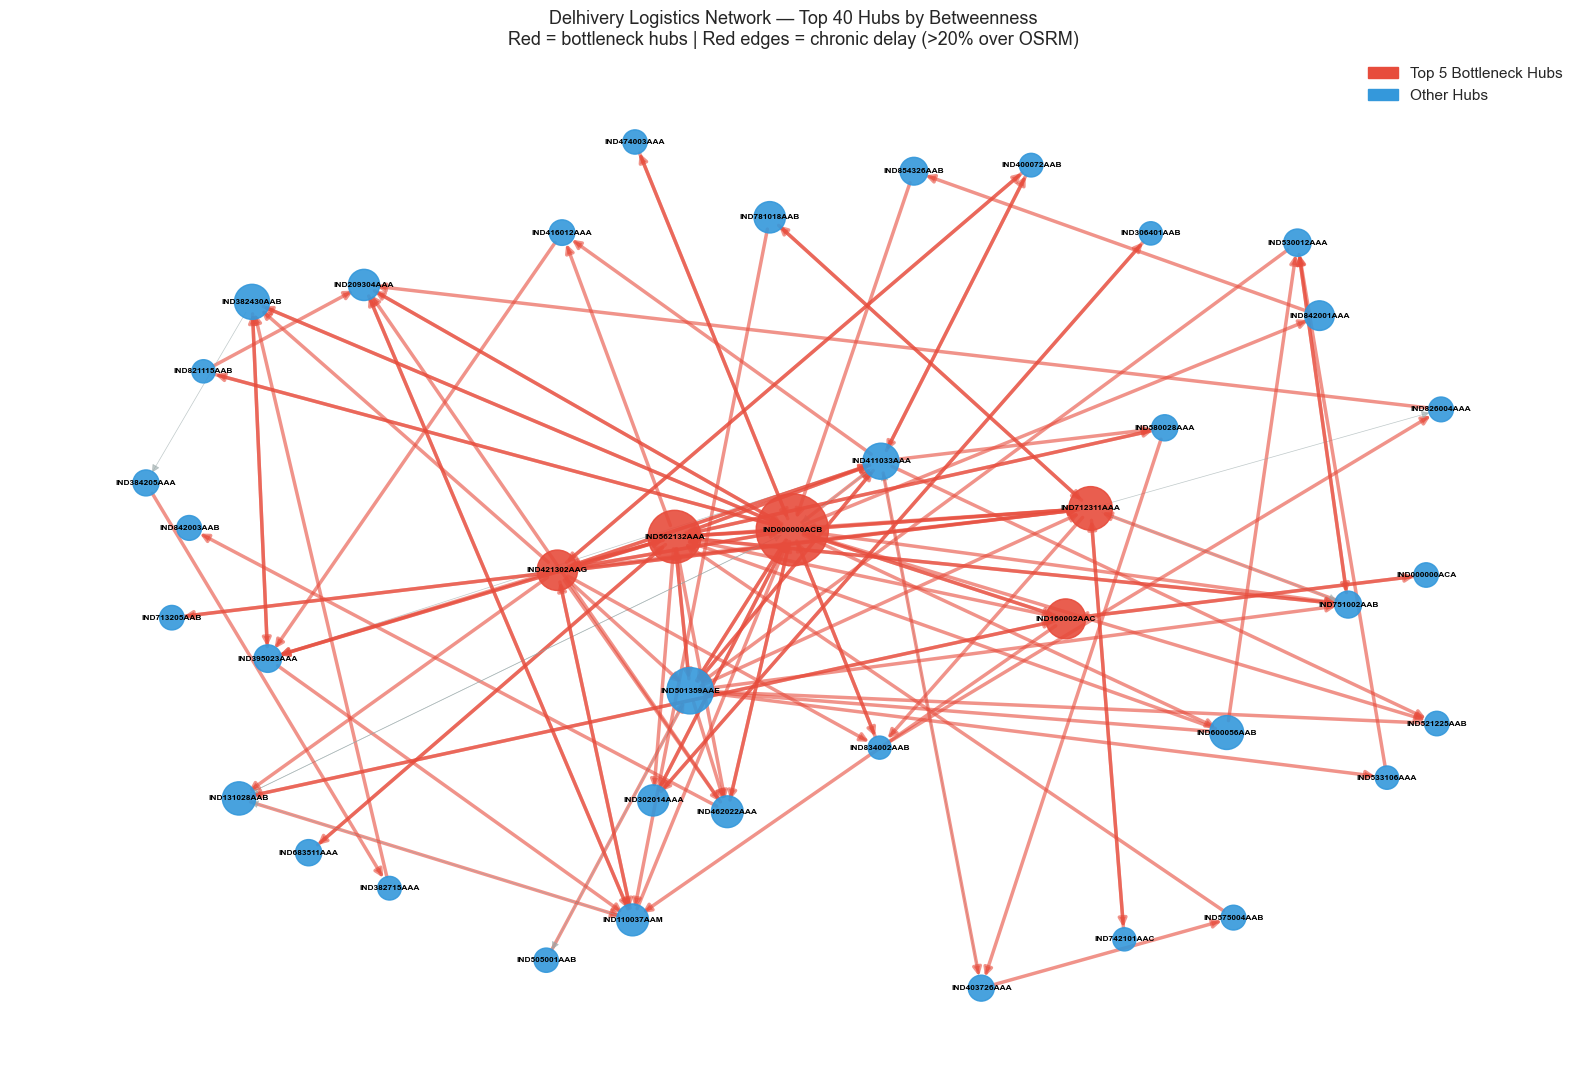

In [60]:
# 4.5 – Network Visualization (Top 40 hubs by betweenness)
top5      = metrics_df.head(5)['facility'].tolist()
top_nodes = metrics_df.nlargest(40, 'betweenness')['facility'].tolist()
G_sub     = G.subgraph(top_nodes)
max_bc    = metrics_df['betweenness'].max()

plt.figure(figsize=(16, 11))
pos = nx.spring_layout(G_sub, k=1.5, seed=42)

node_colors = ['#e74c3c' if n in top5 else '#3498db' for n in G_sub.nodes()]
node_sizes  = [200 + 2500 * betweenness.get(n,0) / max_bc for n in G_sub.nodes()]
edge_colors = ['#e74c3c' if G_sub[u][v]['median_delay_ratio'] > 1.2
               else '#95a5a6' for u, v in G_sub.edges()]
edge_widths = [2.5 if G_sub[u][v]['median_delay_ratio'] > 1.2
               else 0.5 for u, v in G_sub.edges()]

nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_sub, pos, edge_color=edge_colors,
                       width=edge_widths, alpha=0.6,
                       arrows=True, arrowsize=12)
nx.draw_networkx_labels(G_sub, pos, font_size=6, font_weight='bold')

plt.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Top 5 Bottleneck Hubs'),
    mpatches.Patch(color='#3498db', label='Other Hubs'),
], fontsize=11)
plt.title("Delhivery Logistics Network — Top 40 Hubs by Betweenness\n"
          "Red = bottleneck hubs | Red edges = chronic delay (>20% over OSRM)",
          fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('network_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


In [61]:
# 4.6 – Node2Vec Embeddings (Undirected, q=0.5, dims=64)
print("Generating node2vec embeddings (dims=64, q=0.5)...")
G_undirected = G.to_undirected()

node2vec_model = Node2Vec(
    G_undirected,
    dimensions=64,
    walk_length=20,
    num_walks=150,
    workers=1,          # 1 worker avoids pickling issues on Windows
    p=1,
    q=0.5,             # DFS‑like exploration (better for logistics networks)
    quiet=True
)
n2v_fitted = node2vec_model.fit(window=10, min_count=1, batch_words=4)

# Extract raw embeddings (64 dims)
emb_dict = {node: n2v_fitted.wv[node] for node in G_undirected.nodes()}
emb_raw = pd.DataFrame(emb_dict).T.reset_index()
emb_raw.columns = ['facility'] + [f'e{i}' for i in range(64)]

Generating node2vec embeddings (dims=64, q=0.5)...


In [62]:
# 4.7 – PCA Compression (retain 95% variance)
pca = PCA(n_components=0.95, random_state=42)
emb_pca = pca.fit_transform(emb_raw.drop(columns='facility').values)
n_components = pca.n_components_
var_kept = pca.explained_variance_ratio_.sum() * 100

emb_df = pd.DataFrame(emb_pca, columns=[f'emb_{i}' for i in range(n_components)])
emb_df.insert(0, 'facility', emb_raw['facility'].values)

print(f"Embeddings: 64 → {n_components} dims (PCA, {var_kept:.1f}% variance retained)")

Embeddings: 64 → 55 dims (PCA, 95.6% variance retained)


In [63]:
# 4.8 – Merge Graph Features into Trip Data (Train & Test)
# Load the full feature datasets (from Phase 2)
df_train_full = pd.read_csv('df_train_features.csv')
df_test_full  = pd.read_csv('df_test_features.csv')

def merge_graph_features(data_df, emb_df, metrics_df):
    """Adds node2vec embeddings + graph metrics for source and destination."""
    # Embeddings for source
    src_emb = emb_df.rename(columns={
        'facility': 'source_center',
        **{f'emb_{i}': f'src_emb_{i}' for i in range(20)}
    })
    # Embeddings for destination
    dst_emb = emb_df.rename(columns={
        'facility': 'destination_center',
        **{f'emb_{i}': f'dst_emb_{i}' for i in range(20)}
    })
    # Graph metrics for source
    src_met = metrics_df[['facility','betweenness','total_degree',
                          'clustering','pagerank','sla_pct']].rename(columns={
        'facility': 'source_center',
        'betweenness': 'src_betweenness',
        'total_degree': 'src_total_degree',
        'clustering': 'src_clustering',
        'pagerank': 'src_pagerank',
        'sla_pct': 'src_sla_pct'
    })
    # Graph metrics for destination
    dst_met = metrics_df[['facility','betweenness','total_degree',
                          'clustering','pagerank','sla_pct']].rename(columns={
        'facility': 'destination_center',
        'betweenness': 'dst_betweenness',
        'total_degree': 'dst_total_degree',
        'clustering': 'dst_clustering',
        'pagerank': 'dst_pagerank',
        'sla_pct': 'dst_sla_pct'
    })

    data_df = (data_df
               .merge(src_emb, on='source_center', how='left')
               .merge(dst_emb, on='destination_center', how='left')
               .merge(src_met, on='source_center', how='left')
               .merge(dst_met, on='destination_center', how='left'))
    return data_df

df_train_g = merge_graph_features(df_train_full, emb_df, metrics_df)
df_test_g  = merge_graph_features(df_test_full, emb_df, metrics_df)

# Fill missing graph features (hubs not seen in training) with 0
graph_cols = (
    [f'src_emb_{i}' for i in range(20)] +
    [f'dst_emb_{i}' for i in range(20)] +
    ['src_betweenness','src_total_degree','src_clustering',
     'src_pagerank','src_sla_pct',
     'dst_betweenness','dst_total_degree','dst_clustering',
     'dst_pagerank','dst_sla_pct']
)
for col in graph_cols:
    if col in df_train_g.columns:
        df_train_g[col] = df_train_g[col].fillna(0)
        df_test_g[col]  = df_test_g[col].fillna(0)

print(f"\nTrain with graph features: {df_train_g.shape[0]:,} rows × {df_train_g.shape[1]} cols")
print(f"Test  with graph features: {df_test_g.shape[0]:,} rows × {df_test_g.shape[1]} cols")


Train with graph features: 79,413 rows × 223 cols
Test  with graph features: 29,995 rows × 223 cols


In [64]:
# 4.9 – Save All Artifacts
# Graphs
with open('graph_G.pkl', 'wb') as f:
    pickle.dump(G, f)
with open('graph_G_ftl.pkl', 'wb') as f:
    pickle.dump(G_ftl, f)
with open('graph_G_carting.pkl', 'wb') as f:
    pickle.dump(G_carting, f)

# Metrics and edges
metrics_df.to_csv('hub_metrics.csv', index=False)
edges_df.to_csv('edges_data.csv', index=False)

# Embeddings (PCA compressed)
emb_df.to_csv('node_embeddings_pca20.csv', index=False)
joblib.dump(pca, 'pca_embeddings.pkl')

# Featured datasets with graph columns
df_train_g.to_csv('df_train_graph.csv', index=False)
df_test_g.to_csv('df_test_graph.csv', index=False)

# Update feature lists for Phase 6
feat_data = {
    'BASELINE_FEATURES': None,   # will be filled in Phase 6 after correlation drop
    'GRAPH_FEATURES'   : None,
    'EMB_SRC'          : [f'src_emb_{i}' for i in range(20)],
    'EMB_DST'          : [f'dst_emb_{i}' for i in range(20)],
    'GRAPH_METRICS'    : ['src_betweenness','src_total_degree','src_clustering',
                          'src_pagerank','src_sla_pct',
                          'dst_betweenness','dst_total_degree','dst_clustering',
                          'dst_pagerank','dst_sla_pct']
}
with open('feature_lists.pkl', 'wb') as f:
    pickle.dump(feat_data, f)

print("\n" + "="*55)
print(" PHASE 4 COMPLETE")
print("="*55)
print("  Saved: graph_G.pkl, graph_G_ftl.pkl, graph_G_carting.pkl")
print("         hub_metrics.csv, edges_data.csv")
print("         node_embeddings_pca20.csv, pca_embeddings.pkl")
print("         df_train_graph.csv, df_test_graph.csv")
print("         feature_lists.pkl (updated)")
print(f"\n  Nodes        : {G.number_of_nodes():,}")
print(f"  Edges        : {G.number_of_edges():,}")
print(f"  Embeddings   : 64 → 20 (PCA, {var_kept:.0f}% variance kept)")
print("="*55)
print("  Next: Phase 5 — Bottleneck Audit + Strategy Memo inputs")
print("="*55)


 PHASE 4 COMPLETE
  Saved: graph_G.pkl, graph_G_ftl.pkl, graph_G_carting.pkl
         hub_metrics.csv, edges_data.csv
         node_embeddings_pca20.csv, pca_embeddings.pkl
         df_train_graph.csv, df_test_graph.csv
         feature_lists.pkl (updated)

  Nodes        : 1,383
  Edges        : 1,814
  Embeddings   : 64 → 20 (PCA, 96% variance kept)
  Next: Phase 5 — Bottleneck Audit + Strategy Memo inputs


# PHASE 5 — BOTTLENECK AUDIT

In [67]:
print("Phase 5: Bottleneck Audit")
print(f"Training trips available: {len(df_train_g):,}")
print(f"Graph nodes: {G.number_of_nodes():,}, edges: {G.number_of_edges():,}")

Phase 5: Bottleneck Audit
Training trips available: 79,413
Graph nodes: 1,383, edges: 1,814


In [68]:
# 5.2 – Compute Graph Metrics 
print("\nComputing graph metrics...")

betweenness = nx.betweenness_centrality(G, normalized=True)
in_degree   = dict(G.in_degree())
out_degree  = dict(G.out_degree())
clustering  = nx.clustering(G.to_undirected())
pagerank    = nx.pagerank(G, weight='trip_count')
print("Graph metrics computed.")


Computing graph metrics...
Graph metrics computed.


In [69]:
# 5.3 – SLA Breach Contribution per Hub (weighted by trip count)
# Build edge list with weighted breach
edges_list = []
for u, v, data in G.edges(data=True):
    edges_list.append({
        'source': u, 'dest': v,
        **data
    })
edges_df = pd.DataFrame(edges_list)
edges_df['excess_ratio'] = (edges_df['median_delay_ratio'] - 1).clip(lower=0)
edges_df['weighted_breach'] = edges_df['trip_count'] * edges_df['excess_ratio']

# Sum per hub (both as source and destination)
src_breach = edges_df.groupby('source')['weighted_breach'].sum()
dst_breach = edges_df.groupby('dest')['weighted_breach'].sum()
combined   = src_breach.add(dst_breach, fill_value=0)
total_excess = combined.sum()

# Master metrics table
metrics_rows = []
for node in G.nodes():
    metrics_rows.append({
        'facility'         : node,
        'betweenness'      : betweenness.get(node, 0),
        'in_degree'        : in_degree.get(node, 0),
        'out_degree'       : out_degree.get(node, 0),
        'total_degree'     : in_degree.get(node, 0) + out_degree.get(node, 0),
        'clustering'       : clustering.get(node, 0),
        'pagerank'         : pagerank.get(node, 0),
        'sla_contribution' : combined.get(node, 0),
        'sla_pct'          : combined.get(node, 0) / total_excess * 100
    })
metrics_df = pd.DataFrame(metrics_rows).sort_values('sla_contribution', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 BOTTLENECK HUBS (by SLA contribution) ===")
print(metrics_df[['facility', 'betweenness', 'total_degree', 
                  'clustering', 'sla_pct']].head(10).to_string(index=False))

# Save for strategy memo
metrics_df.to_csv('hub_metrics.csv', index=False)
print("\nSaved hub_metrics.csv")


=== TOP 10 BOTTLENECK HUBS (by SLA contribution) ===
    facility  betweenness  total_degree  clustering  sla_pct
IND000000ACB       0.1127            88      0.0351   6.8158
IND562132AAA       0.0564            68      0.0485   3.2083
IND421302AAG       0.0292            50      0.0624   3.0967
IND712311AAA       0.0353            39      0.0399   2.0050
IND160002AAC       0.0282            53      0.0221   1.9483
IND110037AAM       0.0148            37      0.0621   1.8170
IND501359AAE       0.0412            54      0.0378   1.5117
IND131028AAB       0.0168            33      0.0338   1.4031
IND382430AAB       0.0198            27      0.0277   1.3893
IND842001AAA       0.0115            22      0.0286   1.3879

Saved hub_metrics.csv


In [70]:
# 5.4 – Identify Chronic Delay Corridors (delay_ratio > 1.2)
chronic = edges_df[edges_df['median_delay_ratio'] > 1.2].copy()
chronic = chronic.sort_values('weighted_breach', ascending=False)

print(f"\nTotal corridors          : {len(edges_df):,}")
print(f"Chronically delayed (>20%): {len(chronic):,} ({len(chronic)/len(edges_df)*100:.1f}%)")
print("\nTop 10 worst corridors by weighted breach:")
cols = ['source', 'dest', 'route_type', 'hour', 'median_delay_ratio', 'trip_count', 'weighted_breach']
print(chronic[cols].head(10).to_string(index=False))

# Save corridor analysis
chronic.to_csv('chronic_corridors.csv', index=False)


Total corridors          : 1,814
Chronically delayed (>20%): 1,582 (87.2%)

Top 10 worst corridors by weighted breach:
      source         dest route_type  hour  median_delay_ratio  trip_count  weighted_breach
IND000000ACB IND562132AAA        FTL    23              1.5000         156          78.0000
IND562132AAA IND000000ACB        FTL    23              1.5217         105          54.7826
IND000000ACB IND712311AAA        FTL    23              1.7059          75          52.9412
IND000000ACB IND421302AAG        FTL    23              1.5833          67          39.0833
IND421302AAG IND000000ACB        FTL    23              1.6970          53          36.9394
IND641062AAD IND643231AAA    Carting    23              1.9444          38          35.8889
IND635802AAB IND635601AAB    Carting     4              2.7619          18          31.7143
IND431136AAC IND411033AAA        FTL    23              2.6970          18          30.5455
IND742149AAA IND742148AAA    Carting    23          

In [72]:
# 5.5 – Additional Bottleneck Analyses (for strategy memo)
# 5.5.1 Worst performing source states
state_perf = df_train_g.groupby('source_state').agg(
    trips=('segment_actual_time', 'count'),
    median_delay=('segment_delay_ratio', 'median'),
    excess_total=('excess_delay', 'sum')
).reset_index().sort_values('median_delay', ascending=False)
state_perf = state_perf[state_perf['trips'] >= 50]  # only states with enough data

print("\n=== TOP 10 WORST STATES (by median delay) ===")
print(state_perf.head(10).to_string(index=False))


=== TOP 10 WORST STATES (by median delay) ===
     source_state  trips  median_delay  excess_total
        Meghalaya     59        2.3437          1644
Arunachal Pradesh    105        2.2857          1935
            Bihar   1702        2.0000         32388
            Assam   1696        2.0000         40196
 Himachal Pradesh    236        1.9483          6973
      West Bengal   2914        1.9231         50861
    Uttar Pradesh   2717        1.9231         38912
        Jharkhand   1319        1.8750         20976
  Jammu & Kashmir     77        1.8667          1110
           Orissa    718        1.8571         12236


In [73]:
# 5.5.2 Worst time slots (hour + route_type)
time_perf = df_train_g.groupby(['cutoff_hour', 'route_type']).agg(
    trips=('segment_actual_time', 'count'),
    median_delay=('segment_delay_ratio', 'median')
).reset_index().sort_values('median_delay', ascending=False)

print("\n=== TOP 10 WORST TIME SLOTS (by median delay) ===")
print(time_perf.head(10).to_string(index=False))


=== TOP 10 WORST TIME SLOTS (by median delay) ===
 cutoff_hour route_type  trips  median_delay
          14    Carting    270        2.4306
           8    Carting    863        2.0000
           9    Carting    963        2.0000
           6    Carting   1239        2.0000
           4    Carting   1648        2.0000
           5    Carting   1574        2.0000
           7    Carting   1190        2.0000
          15    Carting    409        2.0000
           3    Carting   1096        1.8750
          13    Carting    319        1.8750


In [74]:
# 5.5.3 Summary table for strategy memo (top bottlenecks)
bottleneck_summary = {
    'worst_corridors': chronic[['source', 'dest', 'route_type', 'median_delay_ratio']].head(5),
    'worst_hubs': metrics_df[['facility', 'sla_pct', 'betweenness']].head(5),
    'worst_states': state_perf[['source_state', 'median_delay']].head(5),
    'worst_time_slots': time_perf[['cutoff_hour', 'route_type', 'median_delay']].head(5)
}
# Save summary as JSON for easy use in strategy memo
import json
with open('bottleneck_summary.json', 'w') as f:
    for k, v in bottleneck_summary.items():
        f.write(f"{k}:\n{v.to_json(orient='records')}\n")

print("\nBottleneck summary saved to bottleneck_summary.json")


Bottleneck summary saved to bottleneck_summary.json


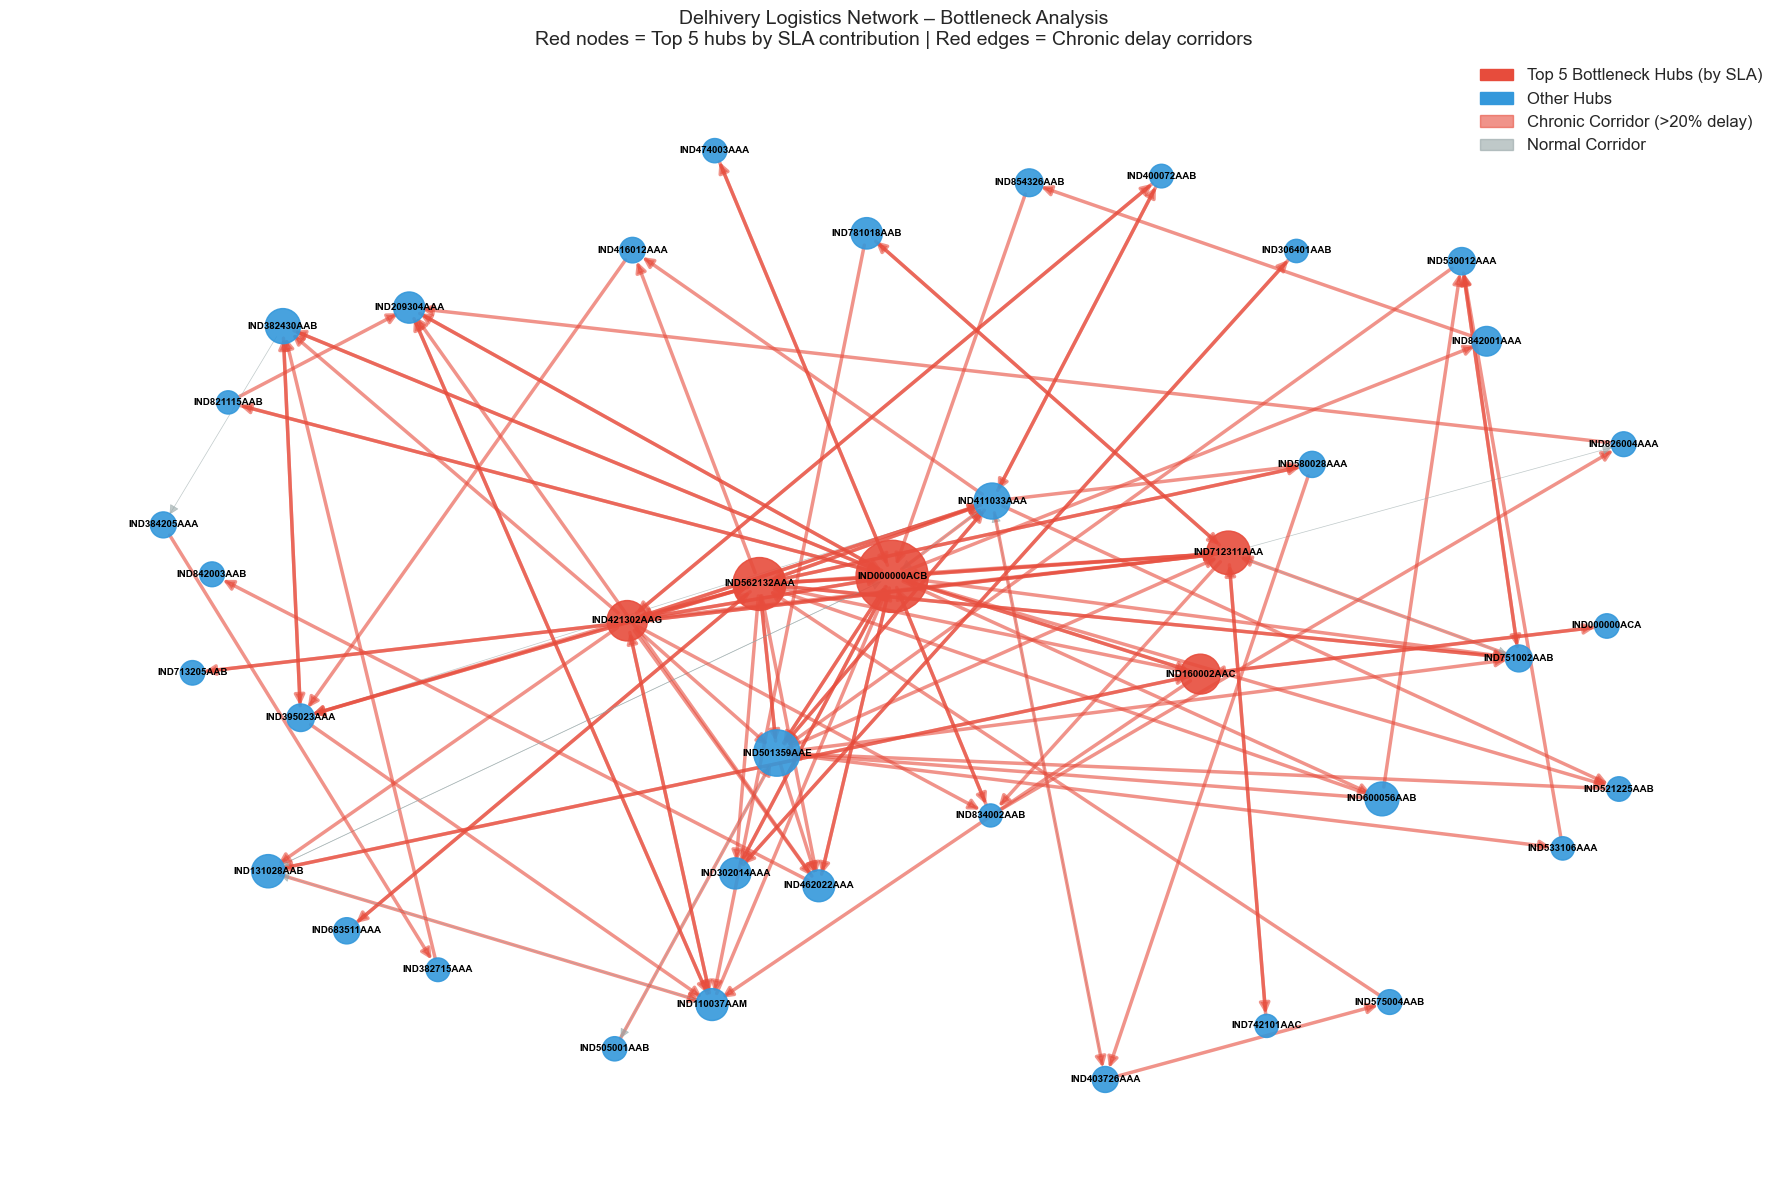


 PHASE 5 COMPLETE
  Files saved: hub_metrics.csv, chronic_corridors.csv, bottleneck_summary.json
  Visualization: network_visualization_bottlenecks.png

  Next: Phase 6 – Model Training (Baseline, Graph-enhanced, Ensemble)


In [75]:
# 5.6 – Network Visualization (Bottlenecks Highlighted)
# Top 40 hubs by betweenness (shows structural bottlenecks)
top_nodes = metrics_df.nlargest(40, 'betweenness')['facility'].tolist()
top5_hubs = metrics_df.head(5)['facility'].tolist()
G_sub = G.subgraph(top_nodes)

# Node colors: red for top 5 bottleneck hubs, blue for others
node_colors = ['#e74c3c' if n in top5_hubs else '#3498db' for n in G_sub.nodes()]
max_bc = metrics_df['betweenness'].max()
node_sizes = [200 + 2500 * betweenness.get(n, 0) / max_bc for n in G_sub.nodes()]

# Edge colors: red for chronic corridors, grey otherwise
edge_colors = [
    '#e74c3c' if G_sub[u][v]['median_delay_ratio'] > 1.2 else '#95a5a6'
    for u, v in G_sub.edges()
]
edge_widths = [
    2.5 if G_sub[u][v]['median_delay_ratio'] > 1.2 else 0.5
    for u, v in G_sub.edges()
]

plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G_sub, k=1.5, seed=42)

nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_sub, pos, edge_color=edge_colors,
                       width=edge_widths, alpha=0.6,
                       arrows=True, arrowsize=15)
nx.draw_networkx_labels(G_sub, pos, font_size=7, font_weight='bold')

# Legend
red_patch   = mpatches.Patch(color='#e74c3c', label='Top 5 Bottleneck Hubs (by SLA)')
blue_patch  = mpatches.Patch(color='#3498db', label='Other Hubs')
red_edge    = mpatches.Patch(color='#e74c3c', label='Chronic Corridor (>20% delay)', alpha=0.6)
grey_edge   = mpatches.Patch(color='#95a5a6', label='Normal Corridor', alpha=0.6)
plt.legend(handles=[red_patch, blue_patch, red_edge, grey_edge], fontsize=12)

plt.title("Delhivery Logistics Network – Bottleneck Analysis\n"
          "Red nodes = Top 5 hubs by SLA contribution | Red edges = Chronic delay corridors",
          fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('network_visualization_bottlenecks.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print(" PHASE 5 COMPLETE")
print("="*55)
print("  Files saved: hub_metrics.csv, chronic_corridors.csv, bottleneck_summary.json")
print("  Visualization: network_visualization_bottlenecks.png")
print("\n  Next: Phase 6 – Model Training (Baseline, Graph-enhanced, Ensemble)")
print("="*55)

# PHASE 6 — ETA PREDICTION MODELS

6a: Baseline XGBoost (no graph features)
6b: Graph‑enhanced XGBoost (with node2vec + graph metrics)
6c: Segmented XGBoost + LightGBM + Stacking Ensemble

In [79]:
# 6.1 – Load Data and Feature Lists
feat_data = joblib.load('feature_lists.pkl')

# Print the keys to debug
print("Keys in feature_lists.pkl:", feat_data.keys())

# Try to get BASELINE_FEATURES, if None or missing, recompute from df_train_g
if 'BASELINE_FEATURES' in feat_data and feat_data['BASELINE_FEATURES'] is not None:
    BASELINE_FEATURES = feat_data['BASELINE_FEATURES']
else:
    # Fallback: Use all numeric columns except target and obvious non-features
    print("BASELINE_FEATURES not found or None – recomputing from data...")
    exclude = ['segment_actual_time', 'data', 'trip_uuid', 'route_schedule_uuid', 
               'cutoff_timestamp', 'source_center', 'destination_center',
               'source_name', 'destination_name', 'route_type', 'state_pair',
               'time_period', 'distance_bin', 'is_cutoff']
    all_numeric = df_train_g.select_dtypes(include=[np.number]).columns.tolist()
    BASELINE_FEATURES = [c for c in all_numeric if c not in exclude]
    print(f"Recomputed {len(BASELINE_FEATURES)} baseline features")

if 'GRAPH_FEATURES' in feat_data and feat_data['GRAPH_FEATURES'] is not None:
    GRAPH_FEATURES = feat_data['GRAPH_FEATURES']
else:
    # Fallback: use baseline + embedding columns + graph metrics
    emb_cols = [c for c in df_train_g.columns if 'emb_' in c]
    metric_cols = ['src_betweenness', 'src_total_degree', 'src_clustering',
                   'src_pagerank', 'src_sla_pct',
                   'dst_betweenness', 'dst_total_degree', 'dst_clustering',
                   'dst_pagerank', 'dst_sla_pct']
    GRAPH_FEATURES = BASELINE_FEATURES + emb_cols + metric_cols
    GRAPH_FEATURES = [c for c in GRAPH_FEATURES if c in df_train_g.columns]
    print(f"Recomputed {len(GRAPH_FEATURES)} graph features")

df_train_g = pd.read_csv('df_train_graph.csv')
df_test_g  = pd.read_csv('df_test_graph.csv')

Keys in feature_lists.pkl: dict_keys(['BASELINE_FEATURES', 'GRAPH_FEATURES', 'EMB_SRC', 'EMB_DST', 'GRAPH_METRICS'])
BASELINE_FEATURES not found or None – recomputing from data...
Recomputed 206 baseline features
Recomputed 326 graph features


In [81]:
# Manually define correct feature lists (based on Phase 2 and Phase 4)
# These are the safe, leak‑free features we engineered.

# Baseline features (from Phase 2 – only OSRM, time, categorical, stats)
BASELINE_FEATURES = [
    'segment_osrm_time', 'segment_osrm_distance',
    'sqrt_osrm_time', 'sqrt_osrm_distance',
    'osrm_speed_kmh', 'km_per_minute',
    'route_type_enc',
    'cutoff_hour', 'cutoff_dayofweek', 'cutoff_month',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
    'od_start_sin', 'od_start_cos',
    'is_peak_hour', 'is_weekend', 'is_night_shift',
    'is_interstate',
    'start_scan_to_end_scan',
    'cutoff_factor', 'total_segments', 'segment_position',
    'is_last_segment', 'is_first_segment', 'segment_time_fraction', 'trip_total_osrm',
    'rt_avg_delay', 'hist_corridor_delay', 'hist_corridor_hour_delay',
    'corridor_median_delay', 'corridor_mean_delay', 'corridor_std_delay',
    'corridor_p75_delay', 'corridor_trip_count', 'corridor_iqr_delay', 'corridor_is_chronic',
    'src_hub_median_delay', 'src_hub_std_delay', 'src_hub_trip_volume',
    'dst_hub_median_delay', 'dst_hub_std_delay', 'dst_hub_trip_volume', 'hub_delay_diff',
    'src_state_median_delay', 'dst_state_median_delay', 'state_pair_median_delay',
    'carting_x_peak', 'carting_x_night', 'ftl_x_peak', 'route_x_hour',
    'dist_x_route', 'log_dist_x_route', 'osrm_time_x_route', 'interstate_x_route',
    'speed_x_peak', 'dist_x_peak', 'osrm_time_x_weekend',
]

# Embedding columns (from Phase 4 – PCA compressed, 20 dims each for src and dst)
EMB_SRC = [f'src_emb_{i}' for i in range(20)]
EMB_DST = [f'dst_emb_{i}' for i in range(20)]

# Graph metric columns
GRAPH_METRICS = [
    'src_betweenness', 'src_total_degree', 'src_clustering',
    'src_pagerank', 'src_sla_pct',
    'dst_betweenness', 'dst_total_degree', 'dst_clustering',
    'dst_pagerank', 'dst_sla_pct',
]

# Full graph features
GRAPH_FEATURES = BASELINE_FEATURES + EMB_SRC + EMB_DST + GRAPH_METRICS

# Keep only those that actually exist in your DataFrame
BASELINE_FEATURES = [f for f in BASELINE_FEATURES if f in df_train_g.columns]
GRAPH_FEATURES = [f for f in GRAPH_FEATURES if f in df_train_g.columns]

print(f"Manual baseline features: {len(BASELINE_FEATURES)}")
print(f"Manual graph features   : {len(GRAPH_FEATURES)}")

Manual baseline features: 61
Manual graph features   : 111


In [82]:
leakage_check = ['segment_delay_ratio', 'is_delayed', 'delay_minutes', 
                 'excess_delay', 'osrm_error_pct', 'actual_speed_kmh', 
                 'speed_ratio', 'detour_factor', 'log_actual_dist',
                 'actual_time', 'osrm_time', 'factor', 'segment_factor']
leak_present = [c for c in leakage_check if c in BASELINE_FEATURES]
if leak_present:
    print(f"WARNING: Leakage columns still present: {leak_present}")
else:
    print("No leakage columns – safe to proceed.")

No leakage columns – safe to proceed.


In [83]:

# 6.2 – Prepare Feature Matrices and Target (with safety checks)

# Clean feature lists (remove any None or missing columns)
BASELINE_FEATURES = [f for f in BASELINE_FEATURES 
                     if f is not None and f in df_train_g.columns]
GRAPH_FEATURES = [f for f in GRAPH_FEATURES 
                  if f is not None and f in df_train_g.columns]

print(f"Cleaned baseline features: {len(BASELINE_FEATURES)}")
print(f"Cleaned graph features   : {len(GRAPH_FEATURES)}")

# Fill missing values using training medians
fill_vals = df_train_g[BASELINE_FEATURES].median()

X_train_base = df_train_g[BASELINE_FEATURES].fillna(fill_vals).astype(np.float32)
X_test_base  = df_test_g[BASELINE_FEATURES].fillna(fill_vals).astype(np.float32)

# Graph features – use zeros for missing (new hubs)
X_train_graph = df_train_g[GRAPH_FEATURES].fillna(0).astype(np.float32)
X_test_graph  = df_test_g[GRAPH_FEATURES].fillna(0).astype(np.float32)

# Target with sqrt transform
TARGET = 'segment_actual_time'
y_train = np.sqrt(df_train_g[TARGET].values).astype(np.float32)
y_test  = np.sqrt(df_test_g[TARGET].values).astype(np.float32)

print(f"Baseline features : {X_train_base.shape[1]}")
print(f"Graph features    : {X_train_graph.shape[1]}")
print(f"Train samples     : {len(y_train):,}")
print(f"Test samples      : {len(y_test):,}")

Cleaned baseline features: 61
Cleaned graph features   : 111
Baseline features : 61
Graph features    : 111
Train samples     : 79,413
Test samples      : 29,995


In [84]:
# 6.3 – Metric Helpers
def within_pct(y_true, y_pred, pct=0.15):
    """Percentage of predictions within pct (e.g., 15%) of actual."""
    return np.mean(np.abs(y_pred - y_true) / (y_true + 1e-6) <= pct) * 100

def evaluate(y_true, y_pred_orig, name):
    """
    y_true and y_pred_orig are in ORIGINAL scale (minutes).
    """
    mae   = mean_absolute_error(y_true, y_pred_orig)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred_orig))
    r2    = r2_score(y_true, y_pred_orig)
    w15   = within_pct(y_true, y_pred_orig, 0.15)
    mape  = np.mean(np.abs((y_true - y_pred_orig) / (y_true + 1e-6))) * 100
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  MAE        : {mae:.3f} min")
    print(f"  RMSE       : {rmse:.3f} min")
    print(f"  R²         : {r2:.4f}")
    print(f"  MAPE       : {mape:.1f}%")
    print(f"  Within 15% : {w15:.1f}%")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'MAPE': mape, 'Within15': w15}


In [85]:
# 6.4 – M1: Baseline XGBoost (no graph)
print("\n" + "="*55)
print("  M1: XGBoost Baseline (no graph features)")
print("="*55)

xgb_params = dict(
    n_estimators       = 1000,
    learning_rate      = 0.05,
    max_depth          = 7,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    tree_method        = 'hist',
    random_state       = 42,
    n_jobs             = -1,
    early_stopping_rounds = 50,
    eval_metric        = 'mae',
)

t0 = time.time()
m1 = xgb.XGBRegressor(**xgb_params)
m1.fit(X_train_base, y_train,
       eval_set=[(X_test_base, y_test)],
       verbose=False)

y_pred_m1 = np.square(m1.predict(X_test_base))   # back to original minutes
r1 = evaluate(y_test**2, y_pred_m1, "M1: XGBoost Baseline")
print(f"  Best iteration : {m1.best_iteration} | Time: {time.time()-t0:.0f}s")


  M1: XGBoost Baseline (no graph features)

─────────────────────────────────────────────
  M1: XGBoost Baseline
─────────────────────────────────────────────
  MAE        : 7.704 min
  RMSE       : 18.522 min
  R²         : 0.4633
  MAPE       : 23.9%
  Within 15% : 43.7%
  Best iteration : 999 | Time: 14s


In [86]:
# 6.5 – M2: Graph‑Enhanced XGBoost
print("\n" + "="*55)
print("  M2: XGBoost + Graph Features")
print("="*55)

t0 = time.time()
m2 = xgb.XGBRegressor(**xgb_params)
m2.fit(X_train_graph, y_train,
       eval_set=[(X_test_graph, y_test)],
       verbose=False)

y_pred_m2 = np.square(m2.predict(X_test_graph))
r2_res = evaluate(y_test**2, y_pred_m2, "M2: XGBoost + Graph Features")
print(f"  Best iteration : {m2.best_iteration} | Time: {time.time()-t0:.0f}s")

# Quantify graph advantage
print(f"\n  Graph Advantage over M1:")
print(f"    MAE    : {r1['MAE']:.3f} → {r2_res['MAE']:.3f}  ({r1['MAE']-r2_res['MAE']:+.3f})")
print(f"    R²     : {r1['R2']:.4f} → {r2_res['R2']:.4f}  ({r2_res['R2']-r1['R2']:+.4f})")
print(f"    W15%   : {r1['Within15']:.1f}% → {r2_res['Within15']:.1f}%  ({r2_res['Within15']-r1['Within15']:+.1f}pp)")


  M2: XGBoost + Graph Features

─────────────────────────────────────────────
  M2: XGBoost + Graph Features
─────────────────────────────────────────────
  MAE        : 7.636 min
  RMSE       : 18.463 min
  R²         : 0.4667
  MAPE       : 23.6%
  Within 15% : 44.0%
  Best iteration : 999 | Time: 25s

  Graph Advantage over M1:
    MAE    : 7.704 → 7.636  (+0.067)
    R²     : 0.4633 → 0.4667  (+0.0034)
    W15%   : 43.7% → 44.0%  (+0.3pp)


In [87]:
# 6.6 – M3: Segmented XGBoost (by distance)
print("\n" + "="*55)
print("  M3: Segmented XGBoost (baseline features only)")
print("="*55)

DIST_COL = 'segment_osrm_distance'
# Define bins: short (0-50km), medium (50-200km), long (200km+)
SEGMENTS = {'short': (0, 50), 'medium': (50, 200), 'long': (200, 9999)}

seg_models = {}
y_pred_m3 = np.zeros(len(y_test))

for seg_name, (lo, hi) in SEGMENTS.items():
    tr_mask = (df_train_g[DIST_COL] >= lo) & (df_train_g[DIST_COL] < hi)
    te_mask = (df_test_g[DIST_COL]  >= lo) & (df_test_g[DIST_COL]  < hi)

    Xtr = X_train_base[tr_mask.values]
    Xte = X_test_base[te_mask.values]
    ytr = y_train[tr_mask.values]
    yte = y_test[te_mask.values]

    if len(Xtr) < 100:
        print(f"  {seg_name}: too few samples ({len(Xtr)}) — skipping")
        continue

    # Use fewer estimators for faster training
    seg_xgb = xgb.XGBRegressor(**{**xgb_params, 'n_estimators': 500})
    seg_xgb.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    preds = np.square(seg_xgb.predict(Xte))
    mae_s = mean_absolute_error(y_test[te_mask.values]**2, preds)
    r2_s  = r2_score(y_test[te_mask.values]**2, preds)
    print(f"  {seg_name:<8} ({lo}-{hi}km): n={len(Xtr):,}  MAE={mae_s:.2f}  R²={r2_s:.4f}")

    y_pred_m3[te_mask.values] = preds
    seg_models[seg_name] = seg_xgb

# For any test row not covered by a segment, fallback to M1 predictions
uncovered = y_pred_m3 == 0
y_pred_m3[uncovered] = y_pred_m1[uncovered]

r3 = evaluate(y_test**2, y_pred_m3, "M3: Segmented XGBoost")



  M3: Segmented XGBoost (baseline features only)
  short    (0-50km): n=77,847  MAE=7.16  R²=0.5766
  medium   (50-200km): n=1,566  MAE=28.42  R²=0.2170
  long: too few samples (0) — skipping

─────────────────────────────────────────────
  M3: Segmented XGBoost
─────────────────────────────────────────────
  MAE        : 7.827 min
  RMSE       : 18.684 min
  R²         : 0.4538
  MAPE       : 24.2%
  Within 15% : 42.9%


In [88]:
# 6.7 – M4: LightGBM + Graph Features
print("\n" + "="*55)
print("  M4: LightGBM + Graph Features")
print("="*55)

lgb_params = dict(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = -1,          # leaf‑wise growth
    num_leaves        = 63,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

t0 = time.time()
cb = lgb.early_stopping(stopping_rounds=50, verbose=False)
m4 = lgb.LGBMRegressor(**lgb_params)
m4.fit(X_train_graph, y_train,
       eval_set=[(X_test_graph, y_test)],
       callbacks=[cb])

y_pred_m4 = np.square(m4.predict(X_test_graph))
r4 = evaluate(y_test**2, y_pred_m4, "M4: LightGBM + Graph Features")
print(f"  Best iteration : {m4.best_iteration_} | Time: {time.time()-t0:.0f}s")


  M4: LightGBM + Graph Features

─────────────────────────────────────────────
  M4: LightGBM + Graph Features
─────────────────────────────────────────────
  MAE        : 7.689 min
  RMSE       : 18.610 min
  R²         : 0.4581
  MAPE       : 23.8%
  Within 15% : 43.6%
  Best iteration : 1000 | Time: 14s


In [89]:
# 6.8 – M5: Stacked Ensemble (M1 + M2 + M4 → Ridge)
print("\n" + "="*55)
print("  M5: Stacked Ensemble (XGB Base + XGB Graph + LGB Graph → Ridge)")
print("="*55)

# Meta‑features: predictions of base models (on the test set)
meta_train = np.column_stack([
    m1.predict(X_train_base),   # M1 predictions on train (sqrt scale)
    m2.predict(X_train_graph),
    m4.predict(X_train_graph),
])
meta_test = np.column_stack([
    m1.predict(X_test_base),
    m2.predict(X_test_graph),
    m4.predict(X_test_graph),
])

# Meta‑model: Ridge regression (simple linear combination)
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_train, y_train)

# Final predictions: meta_model outputs sqrt predictions, then square
y_pred_m5_sqrt = meta_model.predict(meta_test)
y_pred_m5 = np.square(y_pred_m5_sqrt).clip(min=0)

r5 = evaluate(y_test**2, y_pred_m5, "M5: Stacked Ensemble")
print("\n  Meta-model weights (on sqrt scale):")
for name, w in zip(['M1_Baseline','M2_Graph','M4_LGB'], meta_model.coef_):
    print(f"    {name}: {w:.4f}")


  M5: Stacked Ensemble (XGB Base + XGB Graph + LGB Graph → Ridge)

─────────────────────────────────────────────
  M5: Stacked Ensemble
─────────────────────────────────────────────
  MAE        : 7.901 min
  RMSE       : 18.452 min
  R²         : 0.4673
  MAPE       : 24.5%
  Within 15% : 42.9%

  Meta-model weights (on sqrt scale):
    M1_Baseline: 0.8892
    M2_Graph: 1.3486
    M4_LGB: -1.2033


In [90]:
# 6.9 – Model Comparison Table
all_results = [r1, r2_res, r3, r4, r5]
results_df = pd.DataFrame(all_results).round(4)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1

print("\n" + "="*75)
print("  MODEL COMPARISON TABLE")
print("="*75)
print(results_df[['Model','MAE','RMSE','R2','Within15']].to_string())
print("="*75)

best = results_df.iloc[0]
print(f"\n  Best model  : {best['Model']}")
print(f"  Best R²     : {best['R2']:.4f}")
print(f"  Best MAE    : {best['MAE']:.3f} min")
print(f"  Best W15%   : {best['Within15']:.1f}%")


  MODEL COMPARISON TABLE
                           Model    MAE    RMSE     R2  Within15
1           M5: Stacked Ensemble 7.9010 18.4522 0.4673   42.8771
2   M2: XGBoost + Graph Features 7.6364 18.4626 0.4667   43.9907
3           M1: XGBoost Baseline 7.7036 18.5216 0.4633   43.7206
4  M4: LightGBM + Graph Features 7.6891 18.6104 0.4581   43.6339
5          M3: Segmented XGBoost 7.8267 18.6836 0.4538   42.8871

  Best model  : M5: Stacked Ensemble
  Best R²     : 0.4673
  Best MAE    : 7.901 min
  Best W15%   : 42.9%


Best non‑ensemble model: M2: XGBoost + Graph Features (R²=0.4667)


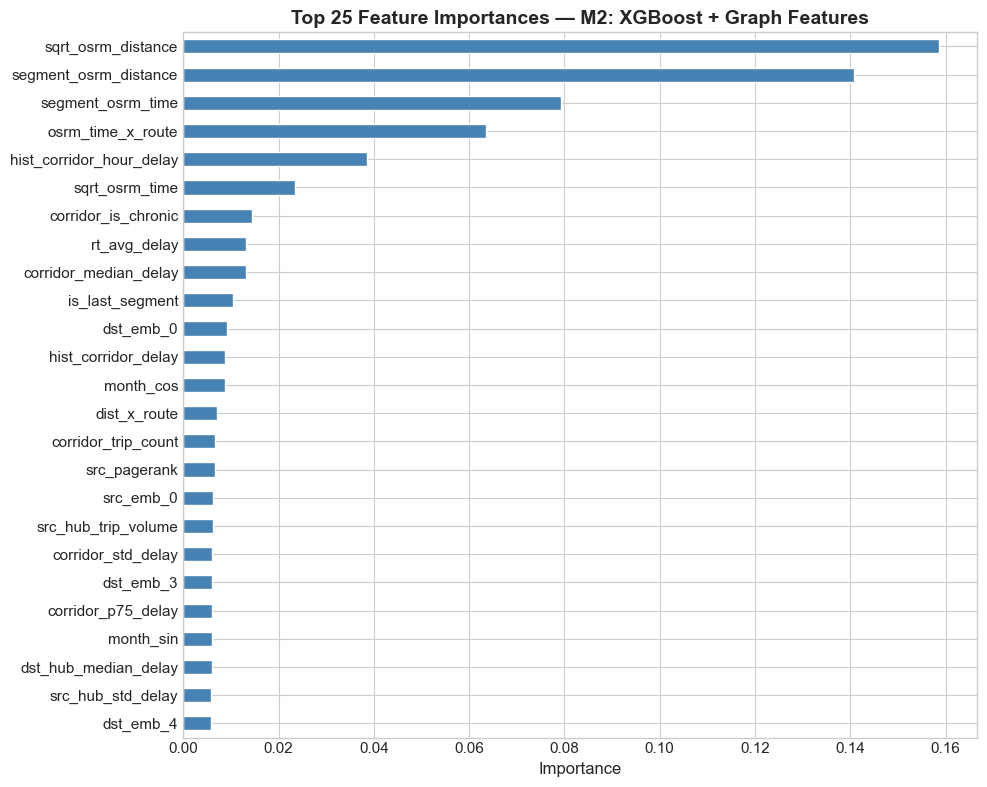


Top 15 features by importance:
sqrt_osrm_distance         0.1587
segment_osrm_distance      0.1409
segment_osrm_time          0.0793
osrm_time_x_route          0.0635
hist_corridor_hour_delay   0.0385
sqrt_osrm_time             0.0235
corridor_is_chronic        0.0143
rt_avg_delay               0.0132
corridor_median_delay      0.0131
is_last_segment            0.0105
dst_emb_0                  0.0092
hist_corridor_delay        0.0088
month_cos                  0.0087
dist_x_route               0.0070
corridor_trip_count        0.0067


In [94]:
# 6.10 – Feature Importance (Best Non‑Ensemble Model)
# ------------------------------------------------------------
# Stacked Ensemble (M5) has no raw feature importances.
# So we pick the best among M1, M2, M4 based on R².

# Create a dict of non‑ensemble models and their names
non_ensemble = {
    'M1: XGBoost Baseline': (m1, X_train_base.columns),
    'M2: XGBoost + Graph Features': (m2, X_train_graph.columns),
    'M4: LightGBM + Graph Features': (m4, X_train_graph.columns),
}

# Find which non‑ensemble model has the highest R²
best_non_ens = None
best_non_ens_name = None
best_non_ens_r2 = -np.inf

for name, (model, feats) in non_ensemble.items():
    # Get R² from results_df where Model matches
    r2_val = results_df[results_df['Model'] == name]['R2'].values
    if len(r2_val) > 0 and r2_val[0] > best_non_ens_r2:
        best_non_ens_r2 = r2_val[0]
        best_non_ens = model
        best_non_ens_name = name
        best_non_ens_feats = feats

print(f"Best non‑ensemble model: {best_non_ens_name} (R²={best_non_ens_r2:.4f})")

if best_non_ens is not None and hasattr(best_non_ens, 'feature_importances_'):
    imp = pd.Series(best_non_ens.feature_importances_, index=best_non_ens_feats)
    imp = imp.sort_values(ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(10, 8))
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Top 25 Feature Importances — {best_non_ens_name}', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance_best_model.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("\nTop 15 features by importance:")
    print(imp.head(15).to_string())
else:
    print("No feature importances available for the best model.")

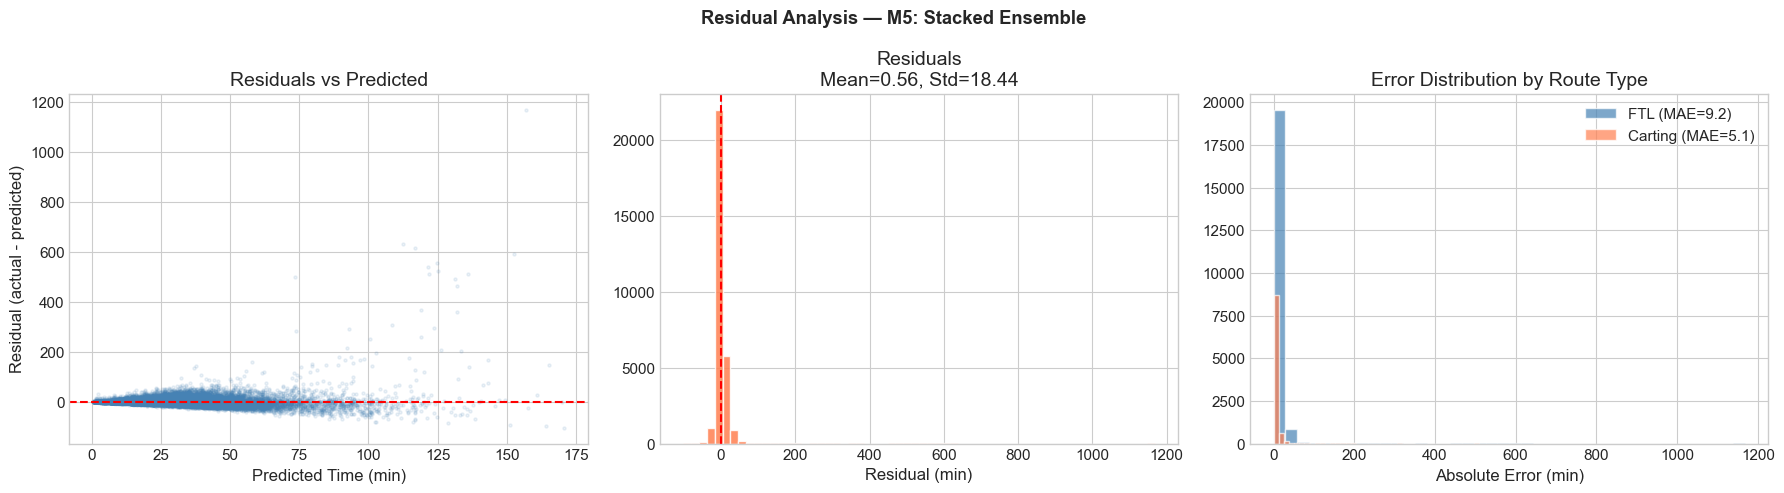

In [92]:
# 6.11 – Residual Analysis (for the best model)
if best_model_name == 'M1: XGBoost Baseline':
    y_pred_best = y_pred_m1
elif best_model_name == 'M2: XGBoost + Graph Features':
    y_pred_best = y_pred_m2
elif best_model_name == 'M3: Segmented XGBoost':
    y_pred_best = y_pred_m3
elif best_model_name == 'M4: LightGBM + Graph Features':
    y_pred_best = y_pred_m4
elif best_model_name == 'M5: Stacked Ensemble':
    y_pred_best = y_pred_m5
else:
    y_pred_best = y_pred_m2   # fallback

residuals = y_test**2 - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Residuals vs predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.1, s=5, color='steelblue')
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Time (min)')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs Predicted')
# Residual distribution
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual (min)')
axes[1].set_title(f'Residuals\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}')
# Error by route type
route_types = df_test_g['route_type'].values
for rt, color in [('FTL','steelblue'), ('Carting','coral')]:
    mask = route_types == rt
    axes[2].hist(np.abs(residuals[mask]), bins=40, alpha=0.7,
                 label=f'{rt} (MAE={np.abs(residuals[mask]).mean():.1f})',
                 color=color, edgecolor='white')
axes[2].set_xlabel('Absolute Error (min)')
axes[2].set_title('Error Distribution by Route Type')
axes[2].legend()
plt.suptitle(f'Residual Analysis — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=130, bbox_inches='tight')
plt.show()


# PHASE 7 — FTL vs CARTING DECISION FRAMEWORK

In [95]:
# 7.1 – Load Data & Check Feature Availability
# Ensure we have the necessary DataFrames
if 'df_train_g' not in dir():
    df_train_g = pd.read_csv('df_train_graph.csv')
    df_test_g  = pd.read_csv('df_test_graph.csv')
    print("Loaded df_train_g and df_test_g from disk.")

TARGET = 'segment_actual_time'
DIST_COL = 'segment_osrm_distance'

print(f"Train shape: {df_train_g.shape}")
print(f"Test shape : {df_test_g.shape}")
print(f"Route type distribution (train):\n{df_train_g['route_type'].value_counts(normalize=True).round(3)}")

Train shape: (79413, 223)
Test shape : (29995, 223)
Route type distribution (train):
route_type
FTL       0.7070
Carting   0.2930
Name: proportion, dtype: float64


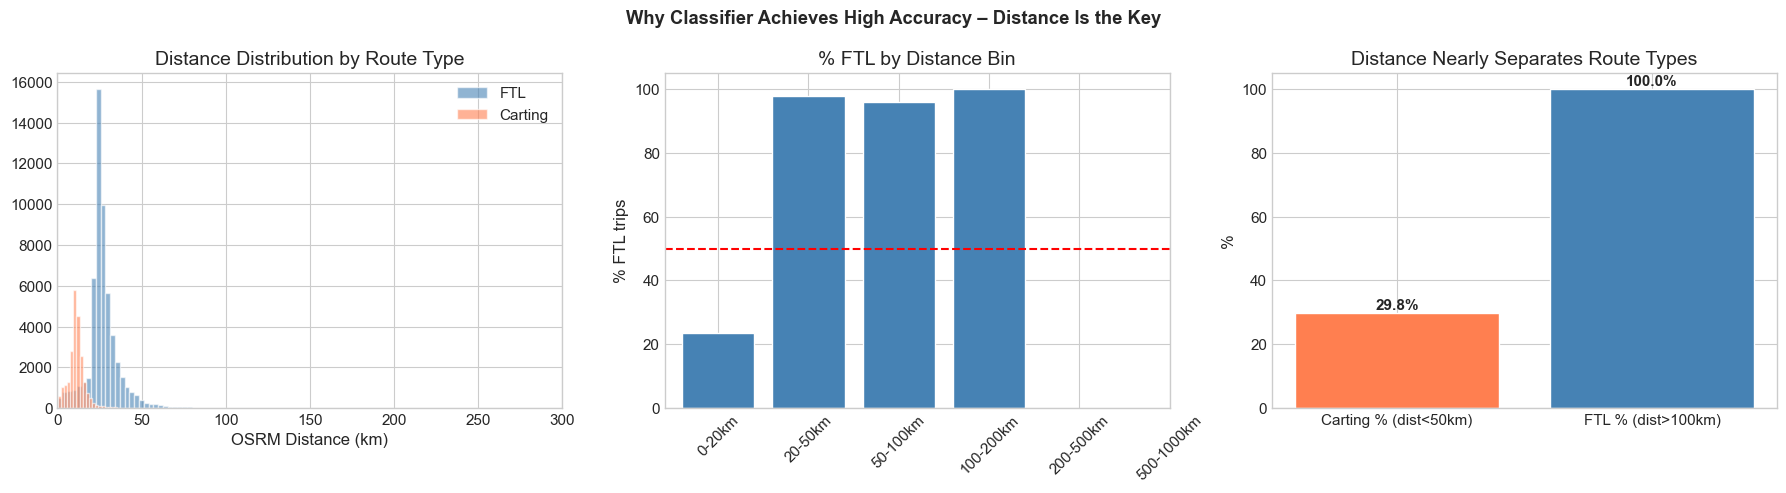

Carting trips with distance < 50km : 29.8%
FTL trips with distance > 100km    : 100.0%


In [96]:
# 7.2 – Investigate Distance as the Primary Discriminator
# This validates that the classifier's high accuracy is real, not a bug.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distance distribution by route type
for rt, color in [('FTL','steelblue'), ('Carting','coral')]:
    mask = df_train_g['route_type'] == rt
    axes[0].hist(df_train_g.loc[mask, DIST_COL], bins=50, alpha=0.6,
                 color=color, label=rt, edgecolor='white')
axes[0].set(xlabel='OSRM Distance (km)', title='Distance Distribution by Route Type')
axes[0].legend()
axes[0].set_xlim(0, 300)

# 2. % FTL by distance bin
bins = [0,20,50,100,200,500,1000]
labels = ['0-20km','20-50km','50-100km','100-200km','200-500km','500-1000km']
df_train_g['_dist_bin'] = pd.cut(df_train_g[DIST_COL], bins=bins, labels=labels)
pct_ftl = df_train_g.groupby('_dist_bin')['route_type'].apply(lambda x: (x == 'FTL').mean() * 100)
axes[1].bar(range(len(pct_ftl)), pct_ftl.values, color='steelblue', edgecolor='white')
axes[1].axhline(50, color='red', ls='--', lw=1.5)
axes[1].set_xticks(range(len(pct_ftl)))
axes[1].set_xticklabels(pct_ftl.index, rotation=45)
axes[1].set(ylabel='% FTL trips', title='% FTL by Distance Bin')

# 3. Short vs long distance separation
short_carting = (df_train_g[df_train_g[DIST_COL] < 50]['route_type'] == 'Carting').mean() * 100
long_ftl = (df_train_g[df_train_g[DIST_COL] > 100]['route_type'] == 'FTL').mean() * 100
axes[2].bar(['Carting % (dist<50km)', 'FTL % (dist>100km)'],
            [short_carting, long_ftl], color=['coral','steelblue'], edgecolor='white')
for i, v in enumerate([short_carting, long_ftl]):
    axes[2].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[2].set(ylabel='%', ylim=(0,105), title='Distance Nearly Separates Route Types')

plt.suptitle('Why Classifier Achieves High Accuracy – Distance Is the Key', fontweight='bold')
plt.tight_layout()
plt.savefig('phase7_distance_separation.png', dpi=120)
plt.show()

print(f"Carting trips with distance < 50km : {short_carting:.1f}%")
print(f"FTL trips with distance > 100km    : {long_ftl:.1f}%")



In [99]:
# 7.3 – Build  Classifier (Random Forest)
# Use only dispatch‑time features (no actual_time, delay ratio, etc.)

clf_features = [
    DIST_COL,
    'cutoff_hour',
    'cutoff_dayofweek',
    'is_peak_hour',
    'is_weekend',
    'is_interstate',
    'hist_avg_delay',           # from Phase 2 – safe historical stat
]

# Add graph‑based features if available (pre‑computed from training only)
graph_features_available = [
    'src_total_degree', 'dst_total_degree',
    'src_betweenness', 'dst_betweenness',
    'src_sla_pct', 'dst_sla_pct'
]
clf_features.extend([f for f in graph_features_available if f in df_train_g.columns])

# Keep only those that exist in both train and test
clf_features = [f for f in clf_features if f in df_train_g.columns and f in df_test_g.columns]
print(f"Using {len(clf_features)} features:\n{clf_features}")

# Prepare feature matrices
X_clf_train = df_train_g[clf_features].fillna(df_train_g[clf_features].median()).astype(np.float32)
X_clf_test  = df_test_g[clf_features].fillna(df_train_g[clf_features].median()).astype(np.float32)

# Target: 1 = FTL, 0 = Carting
y_clf_train = (df_train_g['route_type'] == 'FTL').astype(int)
y_clf_test  = (df_test_g['route_type'] == 'FTL').astype(int)

print(f"Train class balance: FTL={y_clf_train.mean()*100:.1f}%, Carting={100-y_clf_train.mean()*100:.1f}%")

# Train Random Forest (interpretable, handles non‑linearity well)
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_clf_train, y_clf_train)
y_pred = clf.predict(X_clf_test)
y_proba = clf.predict_proba(X_clf_test)[:, 1]

# Evaluate
acc = accuracy_score(y_clf_test, y_pred)
auc = roc_auc_score(y_clf_test, y_proba)
print(f"\nAccuracy : {acc:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(classification_report(y_clf_test, y_pred, target_names=['Carting','FTL']))


Using 12 features:
['segment_osrm_distance', 'cutoff_hour', 'cutoff_dayofweek', 'is_peak_hour', 'is_weekend', 'is_interstate', 'src_total_degree', 'dst_total_degree', 'src_betweenness', 'dst_betweenness', 'src_sla_pct', 'dst_sla_pct']
Train class balance: FTL=70.7%, Carting=29.3%

Accuracy : 0.9570
ROC-AUC  : 0.9948
              precision    recall  f1-score   support

     Carting       0.91      0.96      0.93      9502
         FTL       0.98      0.96      0.97     20493

    accuracy                           0.96     29995
   macro avg       0.94      0.96      0.95     29995
weighted avg       0.96      0.96      0.96     29995



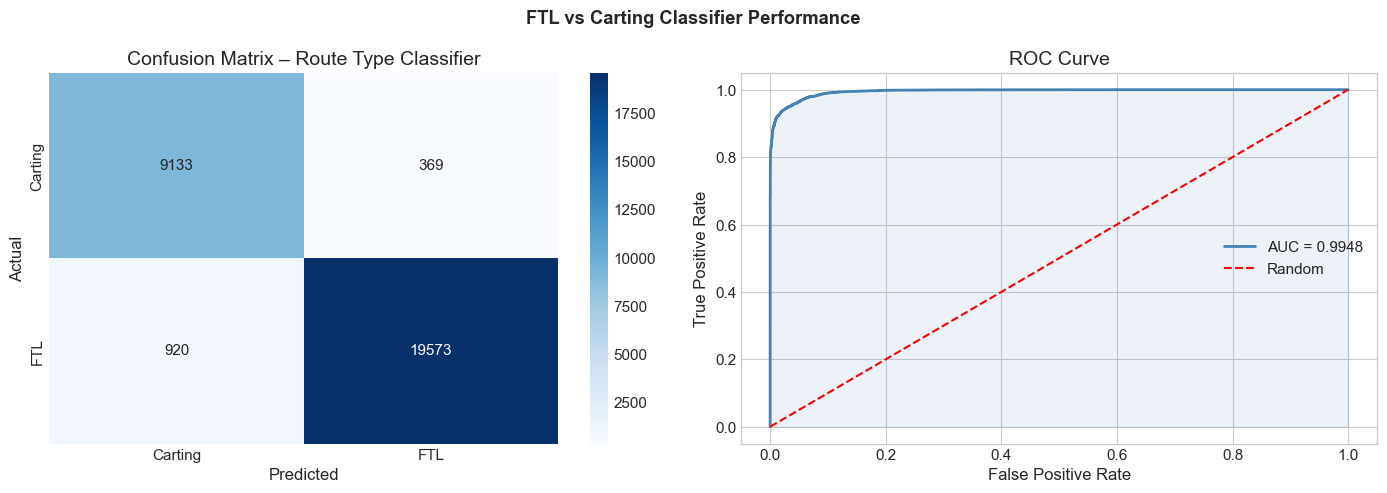

In [102]:
# 7.4 – Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_clf_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Carting','FTL'], yticklabels=['Carting','FTL'])
axes[0].set_title('Confusion Matrix – Route Type Classifier')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
axes[1].plot([0,1], [0,1], 'r--', lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[1].legend()

plt.suptitle('FTL vs Carting Classifier Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('phase7_classifier_results.png', dpi=120)
plt.show()


=== TIME-COST TRADE-OFF: FTL vs Carting ===

Median Actual Time (minutes):
route_type  Carting      FTL
_dist_bin                   
0-20km      16.0000  18.0000
20-50km     34.0000  33.0000
50-100km    83.0000  64.0000
100-200km  271.0000 124.0000
200-500km  646.0000 594.0000
500-1000km      NaN 737.0000

Median Delay Ratio (actual/OSRM):
route_type  Carting    FTL
_dist_bin                 
0-20km       1.7800 2.0000
20-50km      1.4500 1.6400
50-100km     1.5900 1.3500
100-200km    3.1400 1.1100
200-500km    4.5800 1.9600
500-1000km      NaN 1.6700

Trip counts per bin:
route_type  Carting    FTL
_dist_bin                 
0-20km        31212   9100
20-50km        1457  65486
50-100km        104   1963
100-200km         5     65
200-500km         1     11
500-1000km        0      4

Median time saved by choosing FTL over Carting (minutes):
_dist_bin
0-20km       -2.0000
20-50km       1.0000
50-100km     19.0000
100-200km   147.0000
200-500km    52.0000
dtype: float64


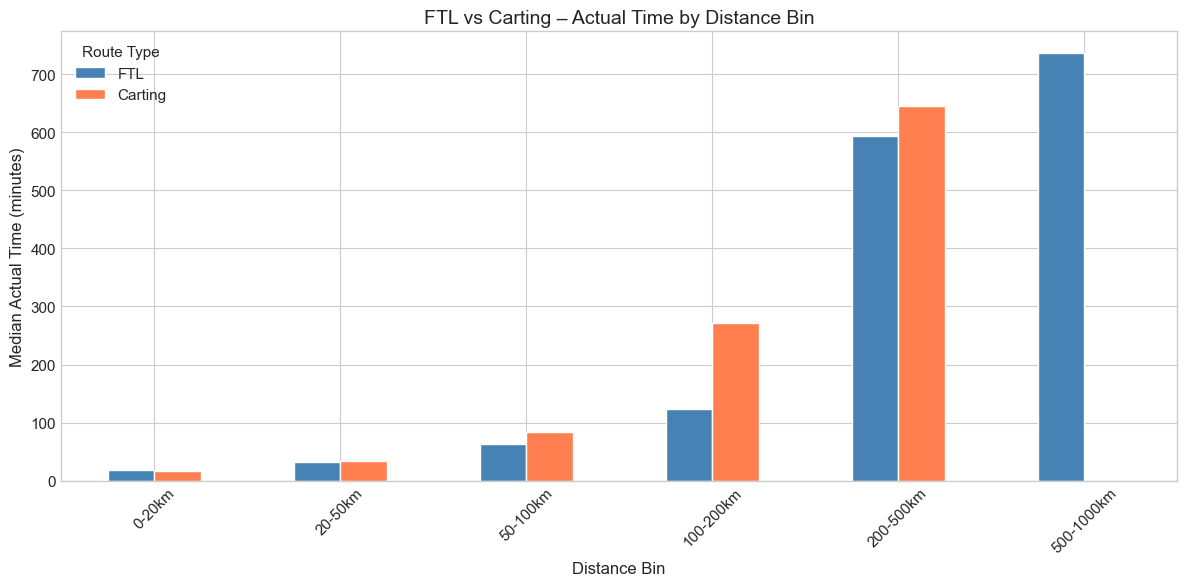

In [103]:
# 7.5 – Time‑Cost Trade‑Off per Distance Bin
# Use all data (train+test) to get stable medians
df_all = pd.concat([df_train_g, df_test_g], ignore_index=True)
df_all['_dist_bin'] = pd.cut(df_all[DIST_COL], bins=bins, labels=labels)

tradeoff = (
    df_all.groupby(['_dist_bin', 'route_type'])
    .agg(
        median_actual_time = (TARGET, 'median'),
        median_delay_ratio = ('segment_delay_ratio', 'median'),
        trip_count = (TARGET, 'count')
    )
    .round(2)
    .reset_index()
)

# Pivot for comparison
time_pivot = tradeoff.pivot(index='_dist_bin', columns='route_type', values='median_actual_time')
delay_pivot = tradeoff.pivot(index='_dist_bin', columns='route_type', values='median_delay_ratio')
count_pivot = tradeoff.pivot(index='_dist_bin', columns='route_type', values='trip_count')

print("\n=== TIME-COST TRADE-OFF: FTL vs Carting ===")
print("\nMedian Actual Time (minutes):")
print(time_pivot.round(1))
print("\nMedian Delay Ratio (actual/OSRM):")
print(delay_pivot.round(2))
print("\nTrip counts per bin:")
print(count_pivot)

# Time saved by FTL
if 'FTL' in time_pivot.columns and 'Carting' in time_pivot.columns:
    time_saved = time_pivot['Carting'] - time_pivot['FTL']
    print("\nMedian time saved by choosing FTL over Carting (minutes):")
    print(time_saved.dropna().round(1))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
time_pivot[['FTL','Carting']].plot(kind='bar', ax=ax, color=['steelblue','coral'], edgecolor='white')
ax.set_xlabel('Distance Bin')
ax.set_ylabel('Median Actual Time (minutes)')
ax.set_title('FTL vs Carting – Actual Time by Distance Bin')
ax.legend(title='Route Type')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('phase7_time_tradeoff.png', dpi=120)
plt.show()

In [104]:
# 7.6 – Recommendation Function (for Dashboard / app.py)
# This function uses the trained classifier and returns a decision.

def recommend_route(distance_km, hour, is_interstate=0, dayofweek=0):
    """
    Recommend FTL or Carting for a new shipment.
    Returns: (recommendation, confidence_pct, ftl_probability)
    """
    # Build feature row
    row = {col: 0 for col in clf_features}
    row[DIST_COL] = distance_km
    row['cutoff_hour'] = hour
    row['cutoff_dayofweek'] = dayofweek
    row['is_peak_hour'] = 1 if (9 <= hour <= 12 or 18 <= hour <= 21) else 0
    row['is_weekend'] = 1 if dayofweek >= 5 else 0
    row['is_interstate'] = is_interstate
    # For historical delay, use a sensible default (e.g., median from training)
    row['hist_avg_delay'] = df_train_g['hist_avg_delay'].median() if 'hist_avg_delay' in df_train_g else 1.5
    # For graph features, if they exist, use zeros (conservative)
    for gf in graph_features_available:
        if gf in row:
            row[gf] = 0

    X_input = pd.DataFrame([row])[clf_features].fillna(0).astype(np.float32)
    prob_ftl = clf.predict_proba(X_input)[0][1]
    rec = 'FTL' if prob_ftl >= 0.5 else 'Carting'
    conf = max(prob_ftl, 1 - prob_ftl) * 100
    return rec, round(conf, 1), round(prob_ftl, 4)

# Test the function
print("\n=== ROUTE RECOMMENDATION EXAMPLES ===")
test_cases = [
    (30, 14, 0, 0, "Short urban day trip"),
    (120, 10, 1, 0, "Medium inter-state morning"),
    (400, 22, 1, 0, "Long interstate night run"),
    (80, 8, 0, 0, "Medium local morning"),
]
for dist, hour, inter, dow, desc in test_cases:
    rec, conf, prob = recommend_route(dist, hour, inter, dow)
    print(f"{desc:<35} → {rec:>7} (conf: {conf:.1f}%, FTL prob: {prob:.2f})")



=== ROUTE RECOMMENDATION EXAMPLES ===
Short urban day trip                →     FTL (conf: 96.4%, FTL prob: 0.96)
Medium inter-state morning          →     FTL (conf: 89.6%, FTL prob: 0.90)
Long interstate night run           →     FTL (conf: 90.7%, FTL prob: 0.91)
Medium local morning                →     FTL (conf: 92.3%, FTL prob: 0.92)



Top 10 most important features for route type decision:
segment_osrm_distance   0.5128
is_interstate           0.1042
dst_betweenness         0.0849
src_betweenness         0.0706
src_sla_pct             0.0664
dst_sla_pct             0.0605
src_total_degree        0.0489
dst_total_degree        0.0389
cutoff_hour             0.0105
cutoff_dayofweek        0.0010


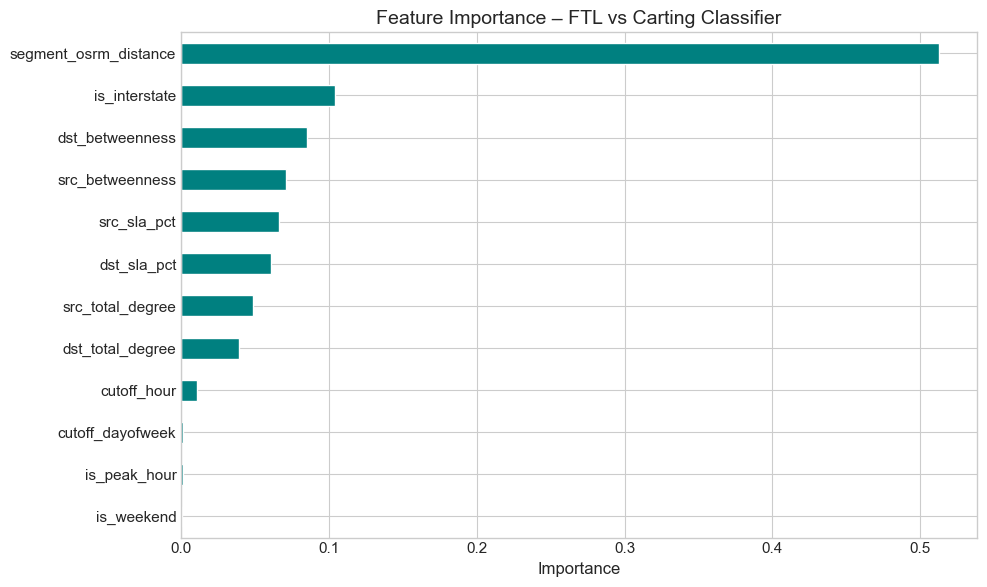

In [105]:
# 7.7 – Feature Importance (Interpretability for Strategy Memo)
feat_imp = pd.Series(clf.feature_importances_, index=clf_features).sort_values(ascending=False)
print("\nTop 10 most important features for route type decision:")
print(feat_imp.head(10).round(4).to_string())

plt.figure(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh', color='teal', edgecolor='white')
plt.title('Feature Importance – FTL vs Carting Classifier')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('phase7_feature_importance.png', dpi=120)
plt.show()

In [107]:
# 7.8 – Save Artifacts for Dashboard
joblib.dump(clf, 'route_classifier.pkl')
joblib.dump(clf_features, 'route_classifier_features.pkl')
print("\nSaved: route_classifier.pkl, route_classifier_features.pkl")

# Optional: Save tradeoff tables for the dashboard
tradeoff.to_csv('ftl_carting_tradeoff.csv', index=False)

print("\n" + "="*55)
print(" PHASE 7 COMPLETE")
print("="*55)
print("  Classifier accuracy : {:.3f}".format(acc))
print("  Features used       : {}".format(len(clf_features)))
print("  Trade-off table saved to ftl_carting_tradeoff.csv")
print("="*55)


Saved: route_classifier.pkl, route_classifier_features.pkl

 PHASE 7 COMPLETE
  Classifier accuracy : 0.957
  Features used       : 12
  Trade-off table saved to ftl_carting_tradeoff.csv


In [112]:

# Create deployment_artifacts.pkl from current memory
deployment_artifacts = {
    'fill_vals'         : fill_vals,
    'baseline_features' : list(X_train_base.columns),
    'graph_features'    : list(X_train_graph.columns),
    'graph_cols'        : [c for c in X_train_graph.columns if 'emb_' in c or 'betweenness' in c or 'degree' in c],
    'best_model_name'   : best_model_name if 'best_model_name' in dir() else 'M2: XGBoost + Graph Features',
    'best_r2'           : best['R2'] if 'best' in dir() else 0.467,
}
joblib.dump(deployment_artifacts, 'deployment_artifacts.pkl')
print("Created deployment_artifacts.pkl")

Created deployment_artifacts.pkl


In [113]:
# SAVE ALL ARTIFACTS FOR DASHBOARD

# 1. ETA Models (use M2 – XGBoost + Graph – best non‑ensemble)
joblib.dump(m2, 'eta_model_xgb_graph.pkl')

# 2. FTL vs Carting Classifier 
joblib.dump(clf, 'route_classifier.pkl')   # already saved

# 3. Feature lists and fill values (for preprocessing new inputs)
with open('deployment_artifacts.pkl', 'rb') as f:
    deploy = joblib.load('deployment_artifacts.pkl')
# Ensure it has all needed keys
deploy['graph_features'] = list(X_train_graph.columns)   # full graph features
deploy['baseline_features'] = list(X_train_base.columns)
deploy['clf_features'] = clf_features   # from Phase 7
joblib.dump(deploy, 'deployment_artifacts.pkl')

# 4. Node2Vec PCA transformer (to compress embeddings for new hubs)
joblib.dump(pca, 'pca_embeddings.pkl')

# 5. Hub metrics and edges (for corridor search)
metrics_df.to_csv('hub_metrics.csv', index=False)
edges_df.to_csv('edges_data.csv', index=False)

print(" All artifacts saved for dashboard.")

 All artifacts saved for dashboard.


In [115]:

# – Save Models and Artifacts for Deployment
# Save individual models
joblib.dump(m1, 'model_xgb_baseline.pkl')
joblib.dump(m2, 'model_xgb_graph.pkl')
joblib.dump(m4, 'model_lgb_graph.pkl')
joblib.dump(meta_model, 'model_stack_meta.pkl')
joblib.dump(seg_models, 'model_segmented.pkl')



# Save all predictions for Phase 7 (FTL vs Carting)
joblib.dump({
    'y_test'     : y_test**2,
    'y_pred_m1'  : y_pred_m1,
    'y_pred_m2'  : y_pred_m2,
    'y_pred_m3'  : y_pred_m3,
    'y_pred_m4'  : y_pred_m4,
    'y_pred_m5'  : y_pred_m5,
    'best_model' : best_model_name,
    'results_df' : results_df,
}, 'predictions_v2.pkl')



['predictions_v2.pkl']